#### 🚀 Tech Challenge FIAP - Análise Exploratória dos Dados (EDA)

Metodologia: CRISP-DM | Fase: Entendimento e Preparação dos Dados

🧑‍🤝‍🧑 **Integrantes do Grupo**:

 ✅ Célia Maria Tomitsuka - RM374490

 ✅ Nelson da Silva Paz - RM374983

 ✅ Nelson Toshikazu Yamamoto - RM374494

 ---


# 3. Análise Exploratória dos Dados (EDA)

Neste item faremos uma análise exploratória com foco em negócio baseado na estatística.
Responderemos às seguintes perguntas:

- Quais fatores parecem mais críticos para a satisfação?
- O que mais gera detratores?
- Existe algum “ponto de ruptura” na experiência do cliente?
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

Índice:

- **3.1**  O que é NPS (Net Promoter Score)
- **3.2**  Pergunta norteadora
- **3.3**  Estrutura de pastas do projeto
- **3.4**  Bibliotecas
- **3.5**  Leitura dos dados brutos (raw)
- **3.6**  Tratamento da base de dados
- **3.6.1**  Lista todos os nomes das colunas da base de dados
- **3.6.2**  Renomeia o nome das colunas para o português
- **3.6.3**  Exibe o dicionario das variáveis
- **3.7** Análise dos números do NPS da base de dados
- **3.8** Mapa de Calor para identificar as correlações das variáveis com a pontuação dp NPS
- **3.9** Preparação da base de dados - transformação de dados "raw" para "processed"
- **3.10** Explorando relações entre variáveis da base de dados por meio de um pairplot
- **3.11** Análise por Perfil do cliente: a região do cliente impacta na nota dada no NPS?
- **3.12** Análise por Perfil do cliente: clientes mais velhos dão notas melhores no NPS?
- **3.13** Tempo de relacionamento (fidelidade): clientes fiéis tendem a dar notas mais altas?
- **3.14** Qualidade da entrega: quanto mais atraso, menor NPS?
- **3.15** Análise por Perfil do cliente: clientes mais velhos dão notas melhores no NPS?
- **3.16** Análise por Perfil do cliente: clientes mais velhos dão notas melhores no NPS?
- **3.17** Análise por Perfil do cliente: clientes mais velhos dão notas melhores no NPS?
- **3.18** Análise por Perfil do cliente: clientes mais velhos dão notas melhores no NPS?
- **3.15** Análise por Perfil do cliente: clientes mais velhos dão notas melhores no NPS?

#### **3.1** O que é NPS (Net Promoter Score)

O **Net Promoter Score (NPS)** é uma métrica utilizada para medir o nível de satisfação e lealdade dos clientes em relação a uma empresa, produto ou serviço.  
Ele é baseado em uma única pergunta:  
> "Em uma escala de 0 a 10, o quanto você recomendaria nossa empresa/produto/serviço a um amigo ou colega?"

Com base nas respostas, os clientes são classificados em três grupos:
- **Promotores (nota 9.0–10.0):** clientes entusiasmados e fiéis, que tendem a recomendar a marca.  
- **Neutros (nota 7.0–8.0):** satisfeitos, mas não necessariamente leais.  
- **Detratores (nota 0–6.9):** insatisfeitos, com maior probabilidade de falar negativamente sobre a marca.

**Obs:** na nossa base de dados, a pontução do NPS (nps_score) é do tipo ponto flutuante de 64 bits.

O resultado varia de **-100 a +100**, indicando o grau de satisfação geral dos clientes.  
Valores positivos sugerem boa experiência e fidelização; valores negativos indicam necessidade de melhorias.

---

#### **3.2**  Pergunta Norteadora: Como podemos utilizar dados operacionais para construir um modelo preditivo capaz de estimar o NPS e antecipar problemas na experiência do cliente?

---

#### **3.3**  Estrutura de pastas do projeto

In [2]:
from pathlib import Path
import sys

# 🔹 1. Definir raiz do projeto
BASE_DIR = Path.cwd().parent  # notebooks/ -> projeto/

# 🔹 2. Paths principais
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

NOTEBOOKS_DIR = BASE_DIR / "notebooks"
SRC_DIR = BASE_DIR / "src"

#### **3.4**  Bibliotecas

In [3]:
# ============================
#  Importação de bibliotecas
# ============================

# Libs - Exploração e manipulação de dados
import pandas as pd
import numpy as np

#Libs Gráfica
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

#Avisos
import warnings
warnings.filterwarnings("ignore")

#### **3.5**  Leitura dos dados brutos (raw)

In [4]:
# ===============================
#  Leitura dos dados brutos (raw)
# ===============================

# Do GitHub
url = "https://raw.githubusercontent.com/FIAPCientistasDados/Dados-Fase1/main/desafio_nps_fase_1.csv"
df_nps_raw = pd.read_csv(url)

# Do projeto
# df_nps_raw = pd.read_csv('/content/sample_data/desafio_nps_fase_1.csv')

# No VSCode
# df_nps_raw = pd.read_csv(RAW_DIR / "tech_challenge_fase1" / "desafio_nps_fase_1.csv")

#### **3.6**   Tratamento e preparação da base de dados
`desafio_nps_fase_1.csv`

##### **3.6.1** Mostra as primeiras 2 linhas da base de dados

In [5]:
df_nps_raw.head(2)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0


##### **3.6.2** Mostra as últimas 2 linhas

In [6]:
df_nps_raw.tail(2)        # últimas

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7
2499,2500,35,Nordeste,109,52500,420.94,1,16.51,4,11,1,34.16,3,1,0,10.0,1,2,7.6


##### **3.6.3** Mostra o tamanho da base de dados

In [7]:
df_nps_raw.shape         # tamanho (linhas, colunas)
print(f'Tamanho do nosso dataset (Linhas, Colunas): {df_nps_raw.shape}' + ' está de acordo com o tamanho fornecido no Dicionário de Dados do Tech Challenge.')

Tamanho do nosso dataset (Linhas, Colunas): (2500, 19) está de acordo com o tamanho fornecido no Dicionário de Dados do Tech Challenge.


In [8]:
# Criar um dicionário de códigos das Regiões dos Clientes
mapa_regioes = {
    'Centro-Oeste': 1,
    'Nordeste': 2,
    'Norte': 3,
    'Sudeste': 4,
    'Sul': 5
}

# Criar nova coluna
df_nps_raw['cod_customer_region'] = df_nps_raw['customer_region'].map(mapa_regioes)

df_nps_raw.shape         # tamanho (linhas, colunas)
print(f'Tamanho do nosso dataset (Linhas, Colunas): {df_nps_raw.shape}' + ' aumentou, pois acrescentamos uma nova coluna para o código da região do cliente.')

Tamanho do nosso dataset (Linhas, Colunas): (2500, 20) aumentou, pois acrescentamos uma nova coluna para o código da região do cliente.


In [9]:
df_nps_raw.columns       # nomes das colunas

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score',
       'cod_customer_region'],
      dtype='str')

##### **3.6.4** Verifica os tipos dos dados (detalhado)

In [10]:
df_nps_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

##### **3.6.5** Mostra os tipos dos dados (resumido)

In [11]:
df_nps_raw.dtypes

customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
cod_customer_region            int64
dtype: object

##### **3.6.6** Verifica a quantidade de valores únicos

In [12]:
df_nps_raw.nunique()

customer_id                  2500
customer_age                   52
customer_region                 5
customer_tenure_months        119
order_id                     2500
order_value                  2457
items_quantity                  6
discount_value               2050
payment_installments           11
delivery_time_days             13
delivery_delay_days             9
freight_value                1897
delivery_attempts               3
customer_service_contacts       8
resolution_time_days           12
nps_score                     101
repeat_purchase_30d             2
complaints_count               12
csat_internal_score            98
cod_customer_region             5
dtype: int64

##### **3.6.7** Resumo estatístico das colunas numéricas da base de dados

In [13]:
df_nps_raw.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,cod_customer_region
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94,3.06
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38,1.41
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70,2.00
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80,3.00
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80,4.00
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00,5.00


##### **3.6.8** Identifica valores ausentes (nulos) na base de dados
Retorna:
`True` se valor nulo (faltando) ou `False` se valor preenchido.





In [14]:
df_nps_raw.isnull()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,cod_customer_region
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2496,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2497,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2498,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


 ##### **3.6.9** Mostra a quantidade de valores nulos por coluna

In [15]:
df_nps_raw.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
cod_customer_region          0
dtype: int64

In [16]:
dados_nulos = df_nps_raw.isnull().sum().sum()
print(f'Quantidade de dados nulos no nosso dataframe: {dados_nulos}')

Quantidade de dados nulos no nosso dataframe: 0


#### *Todas as células da base de dados estão preenchidas sem valores nulos.*

##### **3.6.10** Lista todos os nomes das colunas da base de dados

In [17]:
df_nps_raw.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score',
       'cod_customer_region'],
      dtype='str')

##### **3.6.11**  Renomeia o nome das colunas para o português

In [18]:
mapa_colunas = {
    'customer_id': 'id_cliente',
    'customer_age': 'idade_cliente',
    'customer_region': 'regiao_cliente',
    'customer_tenure_months': 'tempo_cliente_meses',
    'order_id': 'id_pedido',
    'order_value': 'valor_pedido',
    'items_quantity': 'quantidade_itens',
    'discount_value': 'valor_desconto',
    'payment_installments': 'parcelas_pagamento',
    'delivery_time_days': 'tempo_entrega_dias',
    'delivery_delay_days': 'atraso_entrega_dias',
    'freight_value': 'valor_frete',
    'delivery_attempts': 'tentativas_entrega',
    'customer_service_contacts': 'contatos_suporte',
    'resolution_time_days': 'tempo_resolucao_dias',
    'nps_score': 'pontuacao_nps',
    'repeat_purchase_30d': 'recompra_30d',
    'complaints_count': 'quantidade_reclamacoes',
    'csat_internal_score': 'pontuacao_csat_interno',
    'cod_customer_region': 'codigo_regiao_cliente'
}

df_nps_raw_port = df_nps_raw.rename(columns=mapa_colunas)
df_nps_raw_port

,id_cliente,idade_cliente,regiao_cliente,tempo_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_suporte,tempo_resolucao_dias,pontuacao_nps,recompra_30d,quantidade_reclamacoes,pontuacao_csat_interno,codigo_regiao_cliente
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,2
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,5
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,2
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,1
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3,5
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5,5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2,4
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7,5


##### **3.6.12** Exibe o dicionario das variáveis

In [19]:
dicionario_variaveis = pd.DataFrame({
    "variavel": [
        "id_cliente",
        "idade_cliente",
        "regiao_cliente",
        "codigo_regiao_cliente",
        "tempo_cliente_meses",
        "id_pedido",
        "valor_pedido",
        "quantidade_itens",
        "valor_desconto",
        "parcelas_pagamento",
        "tempo_entrega_dias",
        "atraso_entrega_dias",
        "valor_frete",
        "tentativas_entrega",
        "contatos_suporte",
        "tempo_resolucao_dias",
        "pontuacao_nps",
        "recompra_30d",
        "quantidade_reclamacoes",
        "pontuacao_csat_interno"
    ],
    "descricao": [
        "Identificador único do cliente",
        "Idade do cliente",
        "Região geográfica do cliente",
        "Código da região geográfica do cliente",
        "Tempo de relacionamento do cliente com a empresa (em meses)",
        "Identificador único do pedido",
        "Valor total do pedido",
        "Quantidade de itens no pedido",
        "Valor de desconto aplicado ao pedido",
        "Número de parcelas do pagamento",
        "Tempo total de entrega (em dias)",
        "Quantidade de dias de atraso na entrega",
        "Valor do frete",
        "Número de tentativas de entrega",
        "Número de contatos do cliente com o atendimento",
        "Tempo para resolução de problemas (em dias)",
        "Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a compra",
        "Indica se houve recompra em até 30 dias após o pedido (0 = não, 1 = sim)",
        "Número de reclamações registradas pelo cliente",
        "Score interno de satisfação do cliente (CSAT)"
    ],
    "tipo_conceitual": [
        "Identificador",
        "Numérica",
        "Categórica",
        "Numérica",
        "Numérica",
        "Identificador",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica",
        "Numérica (target)",
        "Binária",
        "Numérica",
        "Numérica"
    ],
    "observacao": [
        "Não deve ser usada como variável explicativa",
        "Pode influenciar comportamento do cliente",
        "Usada para segmentação geográfica",
        "Usada para segmentação geográfica",
        "Indica tempo de relacionamento/fidelidade",
        "Usado apenas para identificação do pedido",
        "Variável importante de receita",
        "Indica volume do pedido",
        "Impacta o valor final do pedido",
        "Relaciona-se com poder de compra",
        "Indicador de eficiência logística",
        "Indicador de atraso na entrega",
        "Impacta o custo total do pedido",
        "Pode indicar falhas na entrega",
        "Indicador de qualidade do atendimento",
        "Reflete eficiência na resolução de problemas",
        "Variável alvo de análise (satisfação do cliente)",
        "1 = Sim, 0 = Não",
        "Indicador de insatisfação do cliente",
        "Indicador interno de satisfação (CSAT)"
    ]
})

In [20]:
dicionario_variaveis["existe_na_base"] = dicionario_variaveis["variavel"].isin(df_nps_raw_port.columns)

dicionario_variaveis

,variavel,descricao,tipo_conceitual,observacao,existe_na_base
0,id_cliente,Identificador único do cliente,Identificador,Não deve ser usada como variável explicativa,True
1,idade_cliente,Idade do cliente,Numérica,Pode influenciar comportamento do cliente,True
2,regiao_cliente,Região geográfica do cliente,Categórica,Usada para segmentação geográfica,True
3,codigo_regiao_cliente,Código da região geográfica do cliente,Numérica,Usada para segmentação geográfica,True
4,tempo_cliente_meses,Tempo de relacionamento do cliente com a empre...,Numérica,Indica tempo de relacionamento/fidelidade,True
5,id_pedido,Identificador único do pedido,Identificador,Usado apenas para identificação do pedido,True
6,valor_pedido,Valor total do pedido,Numérica,Variável importante de receita,True
7,quantidade_itens,Quantidade de itens no pedido,Numérica,Indica volume do pedido,True
8,valor_desconto,Valor de desconto aplicado ao pedido,Numérica,Impacta o valor final do pedido,True
9,parcelas_pagamento,Número de parcelas do pagamento,Numérica,Relaciona-se com poder de compra,True


#### **3.7** Análise dos números do NPS da base de dados

📊 ✅ Classificação NPS

Os clientes são divididos em 3 grupos (na nossa base de dados, a pontução do NPS `pontuacao_nps` é do tipo ponto flutuante de 64 bits):

🔴 Detratores (0 a 6.9):
Clientes insatisfeitos, podem falar mal da empresa.
Maior risco de churn (cancelamento).


🟡 Neutros / Passivos (7.0 a 8.9):
Estão satisfeitos, mas não leais, não recomendam ativamente. Podem migrar para concorrentes.


🟢 Promotores (9.0 a 10): Clientes muito satisfeitos e fiéis, recomendam a empresa. Ajudam no crescimento (indicações).



##### **3.7.1** Distribuição das notas de NPS por quantidade de clientes

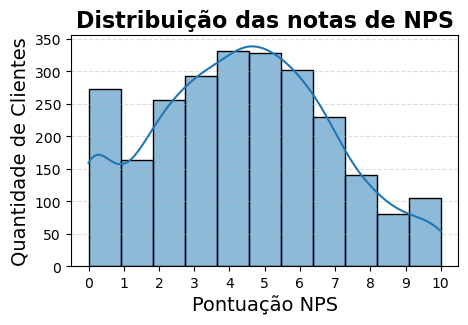

In [21]:
plt.figure(figsize=(5,3))
sns.histplot(df_nps_raw_port['pontuacao_nps'], bins=11, kde=True, color='#1f77b4', edgecolor='black')

plt.title('Distribuição das notas de NPS', fontsize=16, fontweight='bold')
plt.xlabel('Pontuação NPS', fontsize=14)
plt.ylabel('Quantidade de Clientes', fontsize=14)

plt.xticks(range(0,11))
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

##### **3.7.2** Distribuição das notas do NPS (Promotor, Neutro e Detrator)

In [22]:
# Função classificação NPS  
# Mantivemos os valores originais e aplicamos os cortes oficiais da escala: menor que 7 como detrator, de 7 até menor que 9 como neutro, e 9 ou mais como promotor.
# atraso_entrega_dias (tipo: int64)
# pontuacao_nps (tipo: float6)
# Na nossa base de dados consideramos:
# Detrator = 6.9
# Neutro = 7 (inclusive) até 8.9
# Promotor = 9 (inclusive) ou mais


def classificar_nps(score):
    if score >= 9:
        return "Promotor"
    elif score >= 7:
        return "Neutro"
    else:
        return "Detrator"

df_nps_raw_port['categoria_nps'] = df_nps_raw_port['pontuacao_nps'].apply(classificar_nps)
contagem = df_nps_raw_port['categoria_nps'].value_counts()
percentual = df_nps_raw_port['categoria_nps'].value_counts(normalize=True) * 100

resumo_nps = pd.DataFrame({
    'Contagem': contagem,
    'Percentual (%)': percentual.round(2)
})

resumo_nps.loc['Total Geral'] = [
    contagem.sum(),
    100.00
]

print(resumo_nps)

# NPS = %Promotores - %Detratores
nps = percentual.get('Promotor', 0) - percentual.get('Detrator', 0)

print(f"NPS: {nps:.2f}%")


               Contagem  Percentual (%)
categoria_nps                          
Detrator         2109.0           84.36
Neutro            281.0           11.24
Promotor          110.0            4.40
Total Geral      2500.0          100.00
NPS: -79.96%


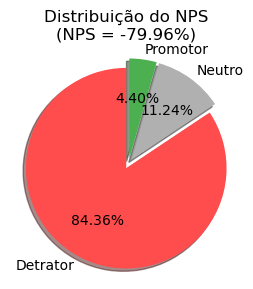

In [23]:
# Contar categorias automaticamente
contagem = df_nps_raw_port['categoria_nps'].value_counts()

# Cores por categoria
cores = {
    'Detrator': '#FF4C4C',
    'Neutro': '#B0B0B0',
    'Promotor': '#4CAF50'
}

# Mapear cores na ordem correta
cores_lista = [cores[c] for c in contagem.index]

# Criar gráfico
plt.figure(figsize=(3, 3))

plt.pie(
    contagem,
    labels=contagem.index,
    autopct='%1.2f%%',
    colors=cores_lista,
    explode=[0.05]*len(contagem),
    startangle=90,
    shadow=True
)

plt.title(f"Distribuição do NPS\n(NPS = {nps:.2f}%)")
plt.axis('equal')

plt.show()

**Interpretando os dados acima:**

_Os resultados apresentados revelam um cenário bastante crítico em relação ao `NPS (Net Promoter Score)`. A grande maioria dos clientes (**84,36%**) encontra-se na categoria de **detratores**, ou seja, pessoas que tiveram experiências negativas ou insatisfatórias e que, em vez de recomendar a empresa, tendem a compartilhar impressões desfavoráveis. Esse número é extremamente elevado e indica um risco significativo para a reputação e para o crescimento orgânico por meio de indicações._

_Por outro lado, apenas **11,24%** dos clientes estão na **faixa neutra**, o que significa que não se sentem motivados a recomendar, mas também não são necessariamente críticos ativos. Esse grupo, embora não prejudique diretamente a imagem, também não contribui para o fortalecimento da marca._

_O dado mais preocupante é que somente **4,40%** dos clientes foram classificados como **promotores**, ou seja, aqueles que efetivamente recomendariam a empresa a outras pessoas. Esse percentual é muito baixo e mostra que há pouca base de defensores da marca._

_O índice final de NPS, calculado em **-79,96%**, confirma esse quadro **negativo**. Como o NPS varia de -100% a +100%, esse resultado está muito próximo do extremo inferior, sinalizando uma insatisfação generalizada. Em termos práticos, significa que a experiência oferecida pela empresa não está atendendo às expectativas da maioria dos clientes, e há uma necessidade urgente de revisão de processos, produtos, serviços e relacionamento._

#### **3.8** Mapa de Calor para identificar as correlações das variáveis com a pontuação dp NPS

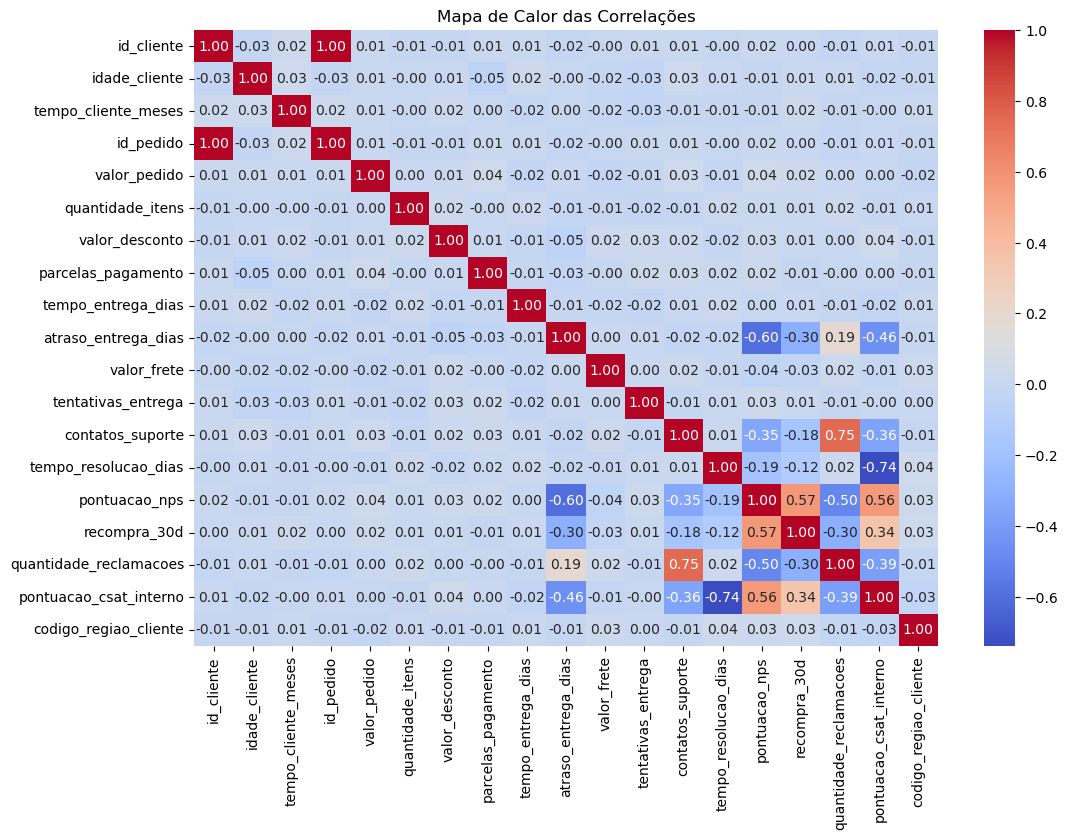

In [24]:
correlacao = df_nps_raw_port.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de Calor das Correlações")
plt.show()

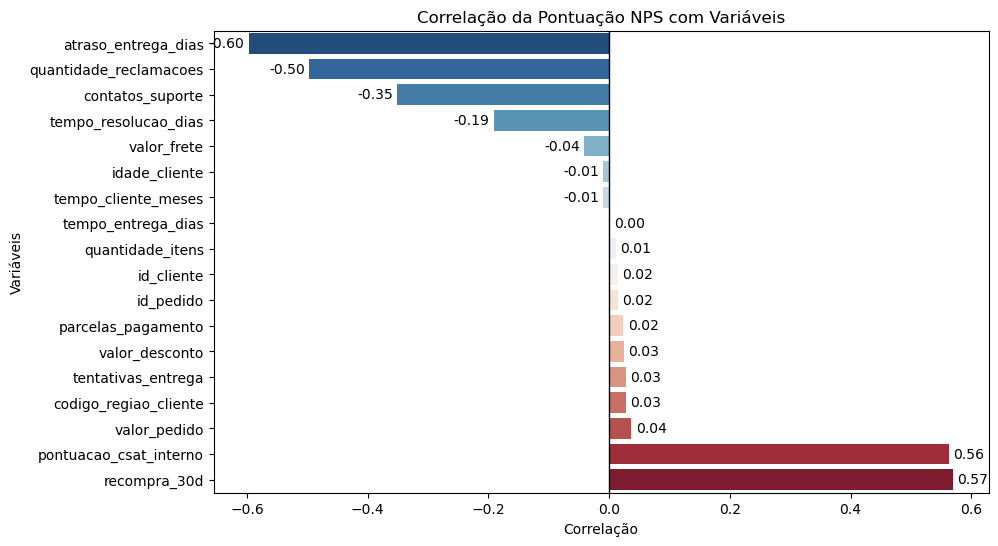

In [25]:
# 1. Criar correlação
correlacao = df_nps_raw_port.corr(numeric_only=True)

# 2. Criar dataframe do NPS
correlacao_nps = (
    correlacao[['pontuacao_nps']]
    .dropna()
    .sort_values(by='pontuacao_nps', ascending=True)
    .reset_index()
)

# 3. Renomear colunas (AQUI nasce 'variavel')
correlacao_nps.columns = ['variavel', 'correlacao']

# 4. Remover a própria variável target
correlacao_nps = correlacao_nps[correlacao_nps['variavel'] != 'pontuacao_nps']

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=correlacao_nps,
    x='correlacao',
    y='variavel',
    palette="RdBu_r"  # invertida: positivo em vermelho, negativo em azul
)

# Adicionar valores ao lado das barras
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=3)

plt.title("Correlação da Pontuação NPS com Variáveis")
plt.xlabel("Correlação")
plt.ylabel("Variáveis")
plt.axvline(0, color='black', linewidth=1)

plt.show()

**Interpretando os dados acima:**

_Os gráficos acima apresentam a correlação entre a **pontuação de NPS** e **diversas variáveis do negócio**, permitindo identificar quais fatores estão mais associados à satisfação ou insatisfação dos clientes._

_`Recompra em 30 dias` (0,57) e `pontuação no CSAT interno` (0,56) são as variáveis com maior correlação positiva com o `NPS`. Isso indica que clientes que tem melhor **pontuação no CSAT interno** e que **voltam a comprar**, tendem a dar **notas mais altas**. Ou seja, eficiência na experiência e fidelização estão diretamente ligadas à satisfação._

_`Atraso na entrega` (-0,60), `quantidade de reclamações` (-0,50) e `contatos com o suporte` (-0,35) apresentam correlação negativa significativa, mostrando que que **clientes que recebem seus pedidos acima do prazo** ou quanto mais o cliente precisa **reclamar ou buscar atendimento**, **menor tende a ser sua nota de NPS**. Esses fatores refletem falhas na logística e na resolução de problemas._

_As demais variáveis como `tempo de resolução`, `valor do frete`, `idade do cliente`, `tempo de relacionamento`, `valor do pedido`, `número de parcelas` e `região do cliente` têm correlação pequena ou próxima de zero, indicando que alguns aspectos de atendimento, financeiros ou demográficos não influenciam fortemente o NPS._

_**Obs:** Baseado na teoria de effect size de Cohen (1988), correlações até ±0,20 são consideradas muito pequenas, elas explicam muito pouco do NPS, então são frequentemente ignoradas na prática._

#### **3.9** Tratamento da base de dados (transformação de dados "raw" para "processed")

In [26]:
df_nps_raw_port.shape         # tamanho (linhas, colunas)
print(f'Tamanho do nosso dataset raw (Linhas, Colunas): {df_nps_raw_port.shape}' + ' com as colunas id_cliente e id_pedido.')

Tamanho do nosso dataset raw (Linhas, Colunas): (2500, 21) com as colunas id_cliente e id_pedido.


In [27]:
# Removeremos as colunas "id_cliente" e "id_pedido", pois não são relevantes para a análise de satisfação
df_nps_raw_port.columns = df_nps_raw_port.columns.str.strip()
df_nps_processed = df_nps_raw_port.drop(columns=["id_cliente", "id_pedido"])

# Salvar em novo arquivo dentro de data/processed
# df_nps_processed.to_csv('/content/sample_data/desafio_nps_fase_1_processado.csv', index=False)

# No VsCode
# Salvar em novo arquivo dentro de data/processed
df_nps_processed.to_csv(PROCESSED_DIR / "desafio_nps_fase_1_processado.csv", index=False)

##### **3.12.1** Tamanho da nova base de dados sem as colunas `id_cliente` e `id_pedido`

In [28]:
df_nps_processed.shape         # tamanho (linhas, colunas)
print(f'Tamanho do nosso dataset (Linhas, Colunas): {df_nps_processed.shape}' + ' sem as colunas id_cliente e id_pedido.')

Tamanho do nosso dataset (Linhas, Colunas): (2500, 19) sem as colunas id_cliente e id_pedido.


##### **3.12.2** Mostra as 2 primeiras e as últimas 2 linhas

In [29]:
pd.concat([df_nps_processed.head(2), df_nps_processed.tail(2)])

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_suporte,tempo_resolucao_dias,pontuacao_nps,recompra_30d,quantidade_reclamacoes,pontuacao_csat_interno,codigo_regiao_cliente,categoria_nps
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,2,Detrator
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,5,Detrator
2498,41,Sul,51,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7,5,Detrator
2499,35,Nordeste,109,420.94,1,16.51,4,11,1,34.16,3,1,0,10.0,1,2,7.6,2,Promotor


### **3.13** Análise Exploratória (EDA)

### **3.14** Explorando relações entre variáveis da base de dados por meio de um pairplot

#### **3.14.1** Comparando variáveis de logística e atendimento

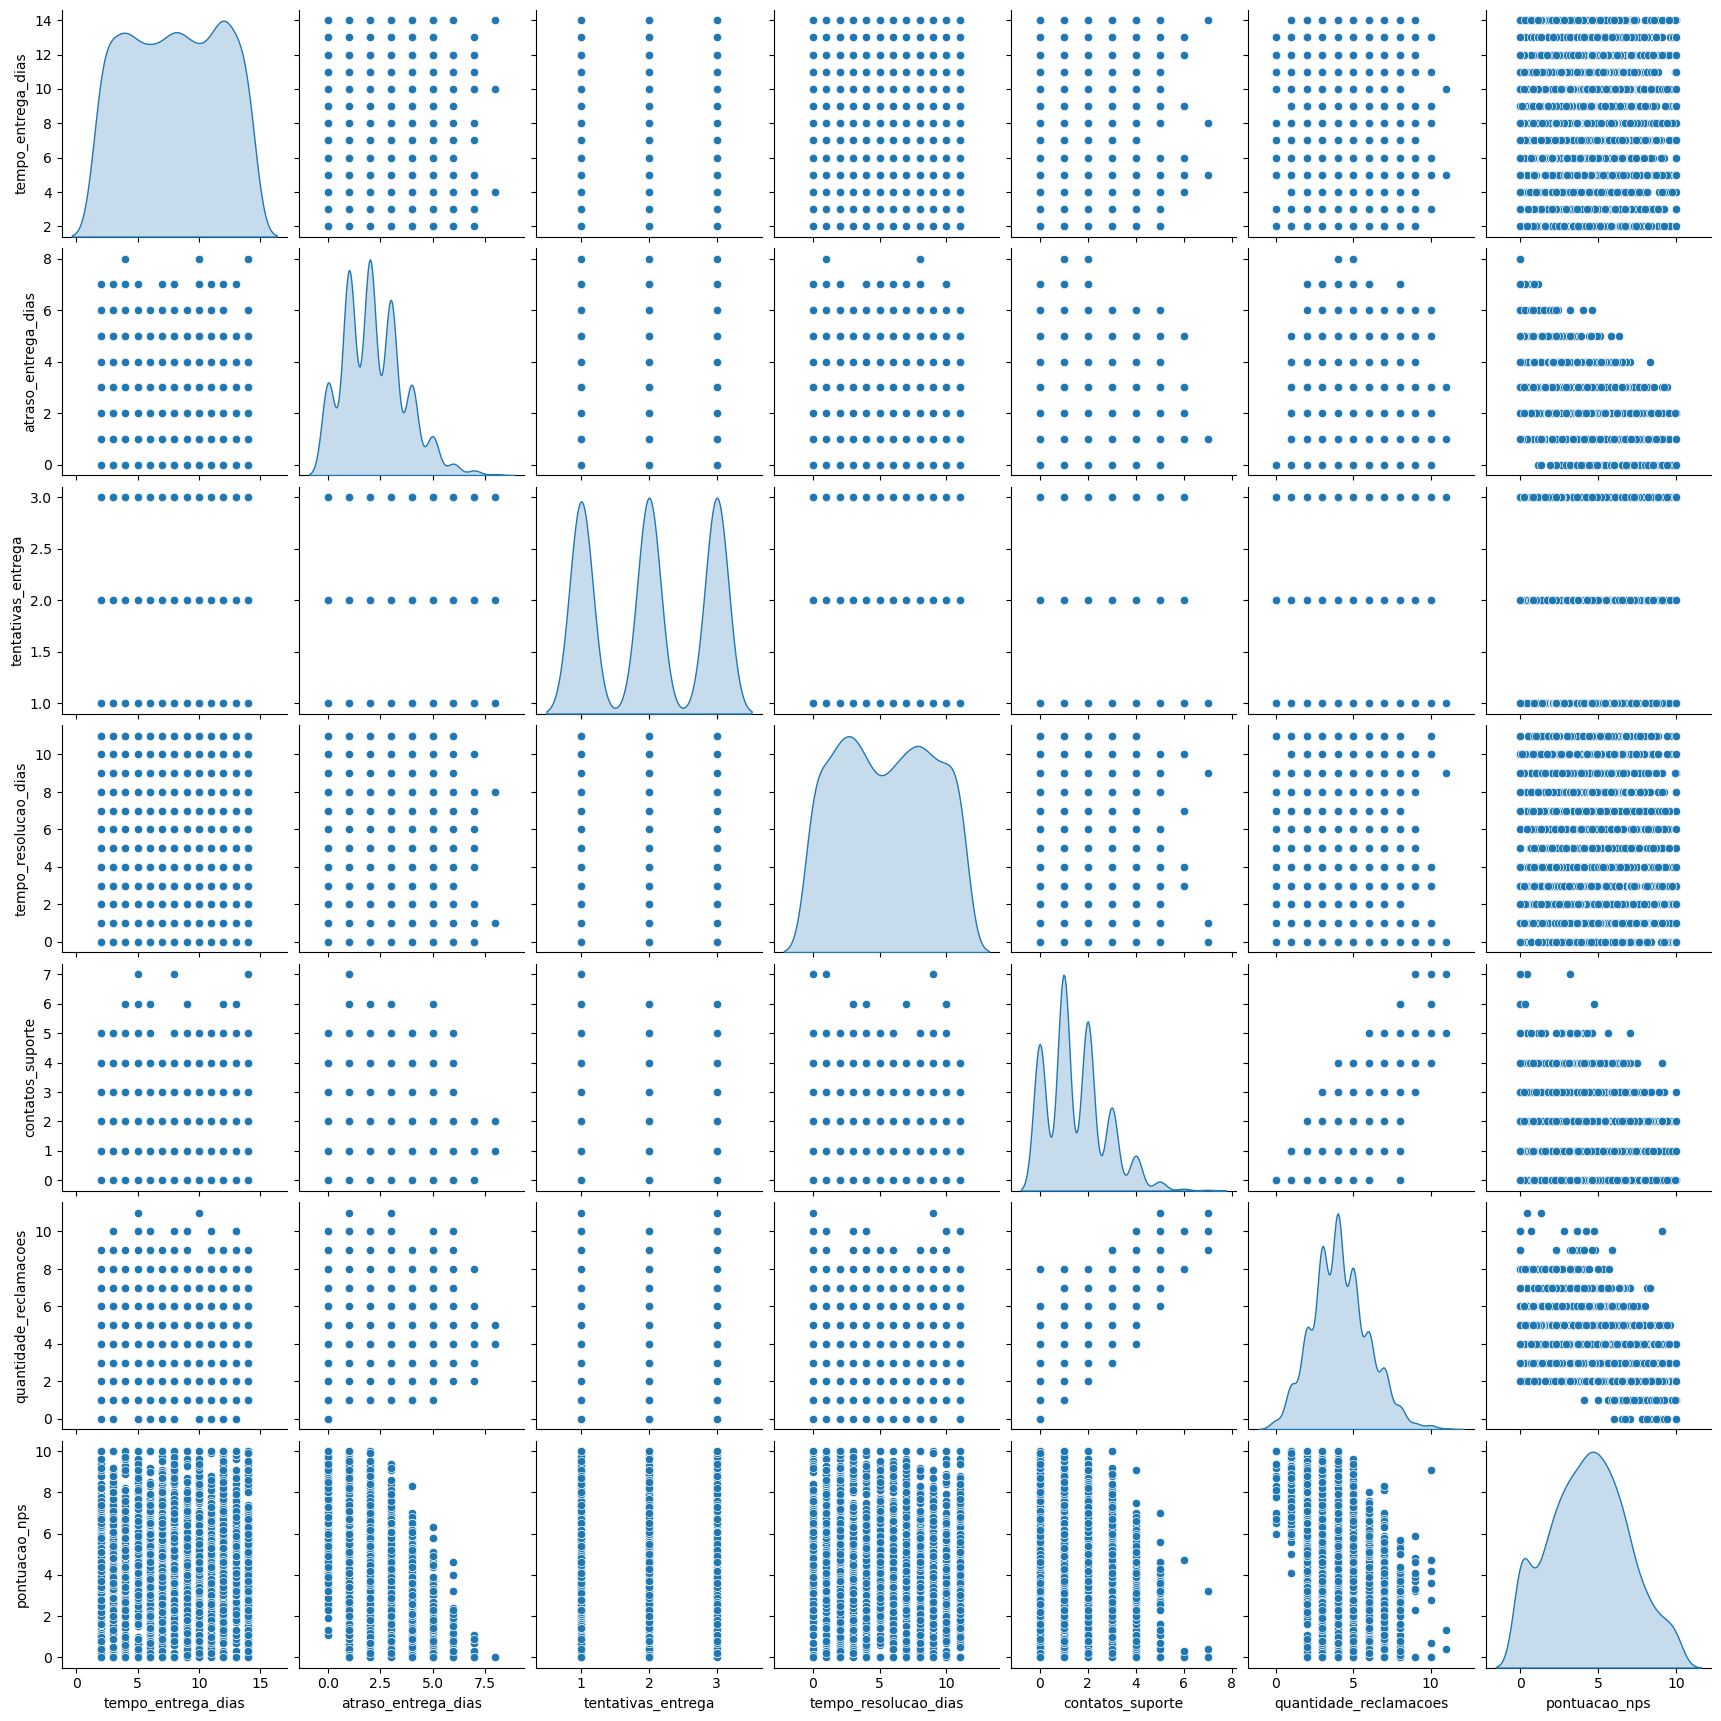

In [30]:
# Compara cada variável com as outras em pares
# Dados logísticos (tempo de entrega, atraso, tentativas)
# Dados de atendimento (contatos, tempo de resolução, quantidade de reclamações)

colunas_pairplot = [
    'tempo_entrega_dias',
    'atraso_entrega_dias',
    'tentativas_entrega',
    'tempo_resolucao_dias',
    'contatos_suporte',
    'quantidade_reclamacoes',
    'pontuacao_nps']

sns.pairplot(
    df_nps_processed[colunas_pairplot],
    diag_kind='kde'
)

**Interpretando os dados:**

_O gráfico acima mostra uma dispersão ampla, sem uma correlação clara ou linear entre o `NPS` e as variáveis `tempo de entrega em dias`, `tentativas de entrega` e `tempo de resolução em dias`. Ou seja, elas não são determinantes diretas da satisfação medida pelo NPS._

_Em relação às variáveis `atraso de entrega em dias`, `contatos suporte`, `quantidade de reclamações` e o `NPS`, **há uma correlação negativa, quanto mais alto os valores, menor as notas de NPS**. Isso sugere que a logística está de fato refletindo na percepção negativa do cliente._

_Estes resultados estão de acordo com o **Mapa de Calor das correlações do NPS (target) com as outras variáveis**, visto no item **3.8**._

#### **3.13.2** Comparando as variáveis do pedido

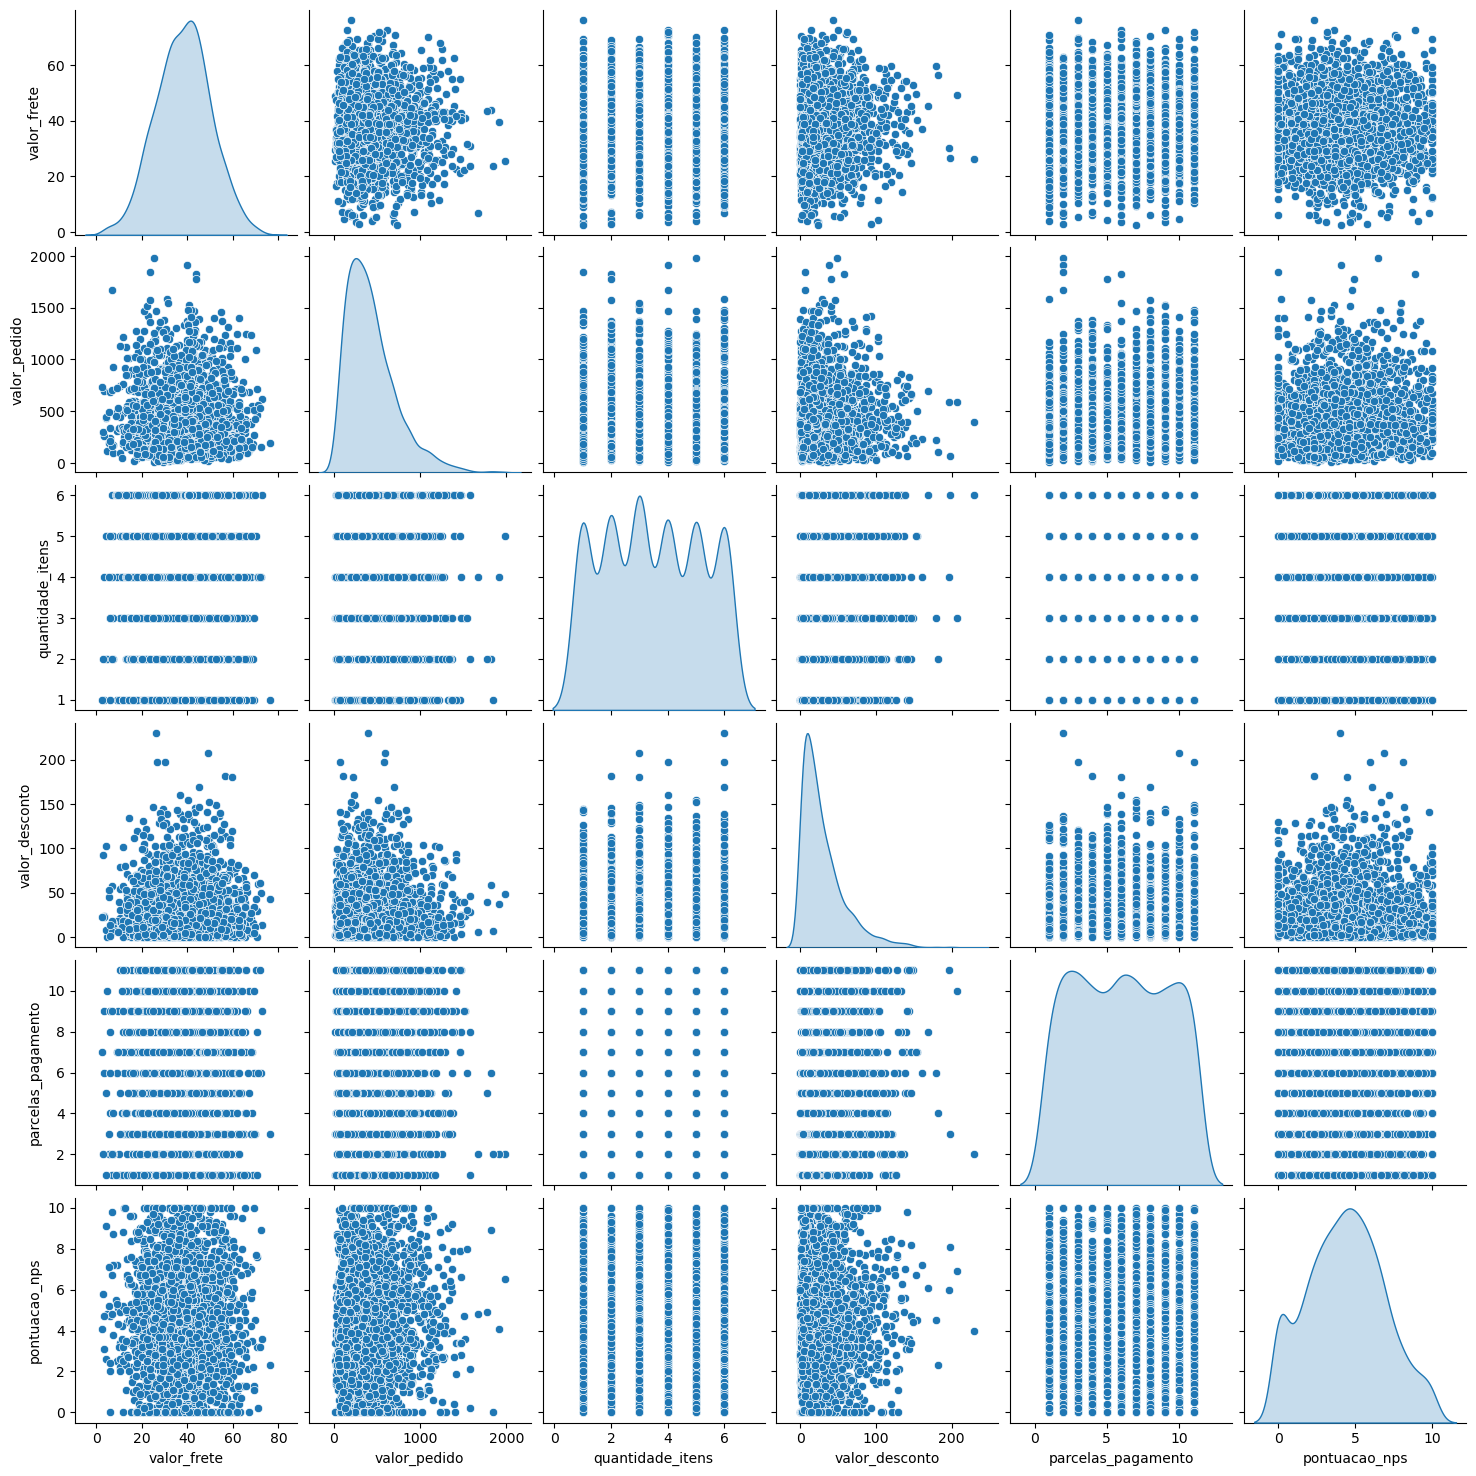

In [31]:
# Dados do pedido (valor, quantidade de itens, desconto, forma de pagamento, frete)

colunas_pairplot = [
    'valor_frete',
    'valor_pedido',
    'quantidade_itens',
    'valor_desconto',
    'parcelas_pagamento',
    'pontuacao_nps']

sns.pairplot(
    df_nps_processed[colunas_pairplot],
    diag_kind='kde'
)

**Interpretando os dados:**

_O gráfico acima mostra uma dispersão ampla, sem uma correlação clara ou linear entre o NPS e as variáveis de pedido, ou seja, fatores como valor, parcelamento ou forma de pagamento não são determinantes diretos da satisfação medida pelo NPS._

_Novamente, estes resultados estão de acordo com o **Mapa de Calor das correlações do NPS (target) com as outras variáveis**, visto no item **3.8**._

#### **3.13.3** Comparando variável do indicador interno de negócio e dados do cliente

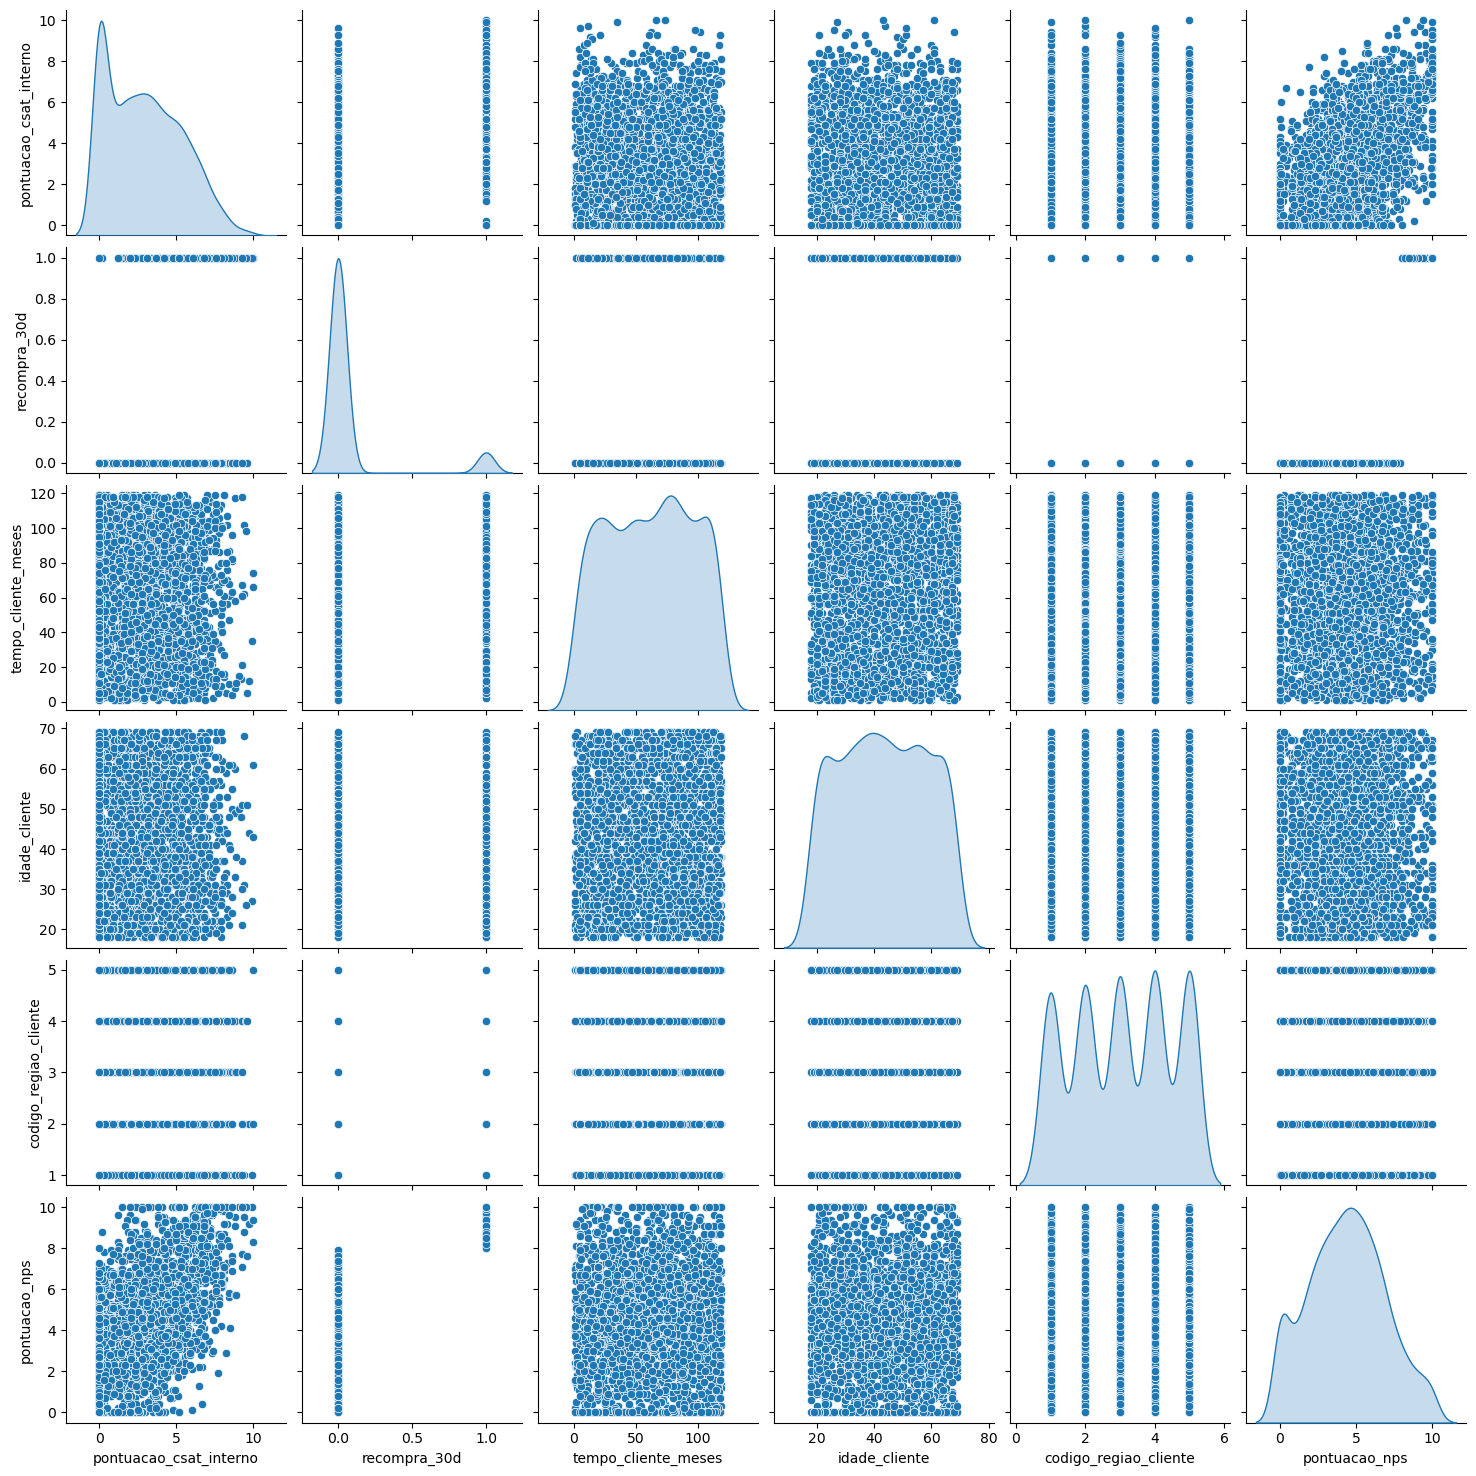

In [32]:
# Indicadores internos de negócio (pontuacao csat interno, recompra em 30d)
# Dados do cliente (tempo do cliente em meses, idade do cliente)
    
colunas_pairplot = [
    'pontuacao_csat_interno',
    'recompra_30d',
    'tempo_cliente_meses',
    'idade_cliente',
    'codigo_regiao_cliente',
    'pontuacao_nps']

sns.pairplot(
    df_nps_processed[colunas_pairplot],
    diag_kind='kde'
)

**Interpretando os dados:**

_O gráfico acima mostra uma dispersão ampla, sem uma correlação clara ou linear entre o `NPS` e as variáveis `idade do cliente`, `tempo de relacionamento/fidelidade (meses)` e a `regiao do cliente`. Ou seja, elas não são determinantes diretas da satisfação medida pelo NPS._

_Em relação à variável `pontuação CSAT` e o `NPS`, existe uma **tendência de alinhamento, clientes com notas mais altas de CSAT interno tendem também a dar notas melhores de NPS**. Isso sugere que a percepção de qualidade interna está de fato refletindo na satisfação do cliente._

_O mesmo ocorre em relação à variável `recompra em 30 dias` e o `NPS`, A dispersão mostra que clientes que **recompram tendem a estar mais concentrados em faixas de NPS mais altas**, isso indica que a recompra pode ser um bom sinal de fidelização._

_Os resultados também estão de acordo com o **Mapa de Calor das correlações do NPS (target) com as outras variáveis**, visto no item **3.8**._

### **3.14** Análise por Perfil do cliente: a região do cliente impacta na nota dada no NPS?

Rótulos de Linha  Média de pontuação NPS  Contagem de regiao_cliente  Perc de regiao_cliente (%)
    Centro-Oeste                  4.2098                         468                       18.72
        Nordeste                  4.4216                         485                       19.40
           Norte                  4.3826                         506                       20.24
         Sudeste                  4.3738                         520                       20.80
             Sul                  4.4910                         521                       20.84
     Total Geral                  4.3786                        2500                      100.00


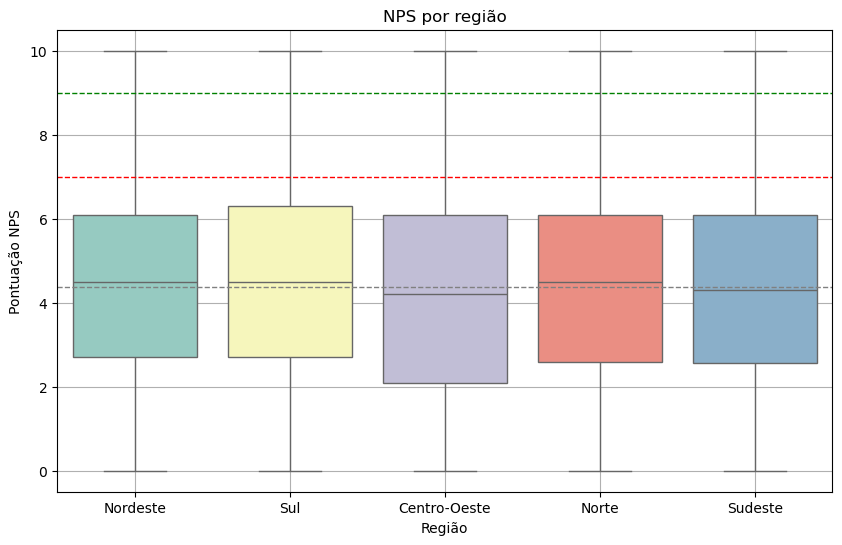

In [33]:
# Calcular média e contagem por dia de atraso
tabela = (
    df_nps_processed.groupby('regiao_cliente')
    .agg(
        media_nps=('pontuacao_nps', 'mean'),
        contagem=('regiao_cliente', 'count')
    )
    .reset_index()
)

# Calcular percentual (mantendo tipo numérico)
tabela['percentual'] = (tabela['contagem'] / tabela['contagem'].sum()) * 100

# Adicionar linha de total geral
total = pd.DataFrame({
    'regiao_cliente': ['Total Geral'],
    'media_nps': [df_nps_processed['pontuacao_nps'].mean()],
    'contagem': [df_nps_processed.shape[0]],
    'percentual': [100.0]
})

# Concatenar e formatar
tabela = pd.concat([tabela, total], ignore_index=True)
tabela['media_nps'] = tabela['media_nps'].round(4)
tabela['percentual'] = tabela['percentual'].round(2)

# Renomear colunas
tabela = tabela.rename(columns={
    'regiao_cliente': 'Rótulos de Linha',
    'media_nps': 'Média de pontuação NPS',
    'contagem': 'Contagem de regiao_cliente',
    'percentual': 'Perc de regiao_cliente (%)'
})

# Exibir tabela
print(tabela.to_string(index=False))


# Visualizar com boxplot
plt.figure(figsize=(10,6))
sns.boxplot(
    x='regiao_cliente',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set3'
)

# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')

plt.title("NPS por região")
plt.xlabel("Região")
plt.ylabel("Pontuação NPS")

# plt.legend()
plt.grid(True)
plt.show()

**Interpretando os dados:**

_No gráfico acima vemos que o NPS não varia muito por região. A tabela nos mostra que os clientes por região estão bem distribuídos, entre 18,7% e 20,8%. O NPS médio geral de 4,38 indica um nível de satisfação baixo, sugerindo predominância de clientes neutros e detratores, com baixa presença de promotores. Ou seja, somente a localização do cliente não é determinante direto da satisfação medida pelo NPS._

_O resultado também está de acordo com o **Mapa de Calor das correlações do NPS (target) com a região do cliente**, onde o valor da correlação é de apenas **0,03**, visto no item **3.8**._

_Também é compatível com o resultado do gráfico de Pairplot visto no item **3.13.3**, onde temos uma dispersão ampla, sem uma correlação clara ou linear entre o `NPS` e a `regiao do cliente`._

### **3.15** Análise por Perfil do cliente: clientes mais velhos dão notas melhores no NPS?

faixa_idade  Média de pontuação NPS  Contagem de clientes por faixa de idade  Perc de clientes por faixa de idade (%)
      18-25                  4.4766                                      389                                    15.56
      26-35                  4.5622                                      465                                    18.60
      36-50                  4.1859                                      747                                    29.88
        50+                  4.4013                                      899                                    35.96
Total Geral                  4.3786                                     2500                                   100.00


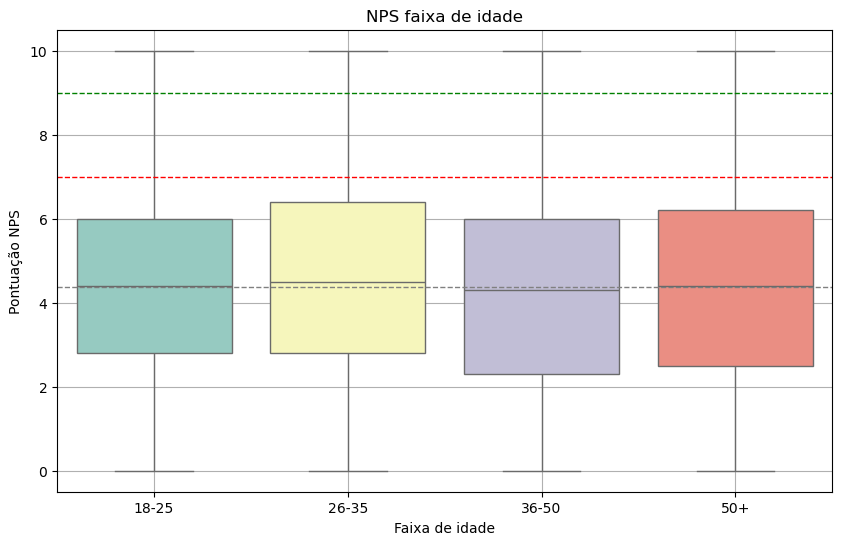

In [34]:
# A faixa de idade dos clientes da base de dados está entre 18 e 69 anos.

df_nps_processed['faixa_idade'] = pd.cut(
    df_nps_processed['idade_cliente'],
    bins=[0, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '50+']
)

# Calcular média e contagem por dia de atraso
tabela = (
    df_nps_processed.groupby('faixa_idade')
    .agg(
        media_nps=('pontuacao_nps', 'mean'),
        contagem=('faixa_idade', 'count')
    )
    .reset_index()
)

# Calcular percentual (mantendo tipo numérico)
tabela['percentual'] = (tabela['contagem'] / tabela['contagem'].sum()) * 100

# Adicionar linha de total geral
total = pd.DataFrame({
    'faixa_idade': ['Total Geral'],
    'media_nps': [df_nps_processed['pontuacao_nps'].mean()],
    'contagem': [df_nps_processed.shape[0]],
    'percentual': [100.0]
})

# Concatenar e formatar
tabela = pd.concat([tabela, total], ignore_index=True)
tabela['media_nps'] = tabela['media_nps'].round(4)
tabela['percentual'] = tabela['percentual'].round(2)

# Renomear colunas
tabela = tabela.rename(columns={
    'Faixa de idade': 'Rótulos de Linha',
    'media_nps': 'Média de pontuação NPS',
    'contagem': 'Contagem de clientes por faixa de idade',
    'percentual': 'Perc de clientes por faixa de idade (%)'
})

# Exibir tabela
print(tabela.to_string(index=False))

# Visualizar com boxplot
plt.figure(figsize=(10,6))
sns.boxplot(
    x='faixa_idade',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set3'
)

# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')

plt.title("NPS faixa de idade")
plt.xlabel("Faixa de idade")
plt.ylabel("Pontuação NPS")

# plt.legend()
plt.grid(True)
plt.show()

**Interpretando os dados:**

_No gráfico acima vemos que o NPS não varia muito por faixa de idade. A tabela nos mostra que a maioria dos clientes está na faixa dos 36 a 69 anos (65.84%). O NPS médio de todas as faixas de idade está próximo à média geral de **4,38** que indica um nível de satisfação baixo, sugerindo predominância de clientes neutros e detratores, com baixa presença de promotores. Ou seja, somente a idade do cliente não é determinante direto da satisfação medida pelo NPS._

_O resultado também está de acordo com o **Mapa de Calor das correlações do NPS (target) com a idade do cliente**, onde o valor da correlação negativo é de apenas **-0,01**, visto no item **3.8**._

_Também é compatível com o resultado do gráfico de Pairplot visto no item **3.13.3**, onde temos uma dispersão ampla, sem uma correlação clara ou linear entre o `NPS` e a `idade do cliente`._

### **3.16** Tempo de relacionamento (fidelidade): clientes fiéis tendem a dar notas mais altas?

categoria_tempo_cliente  Média de pontuação NPS  Contagem de clientes por faixa de tempo de relacionamento  Perc de clientes por faixa de tempo de relacionamento (%)
            Novo [0-6m]                  4.1705                                                        122                                                       4.88
        Recente [7-12m]                  4.1200                                                        120                                                       4.80
 Intermediario [13-24m]                  4.6530                                                        247                                                       9.88
          Fiel [25-60m]                  4.3480                                                        721                                                      28.84
   Super fiel [61-120m]                  4.3869                                                       1290                                                      51.60
    

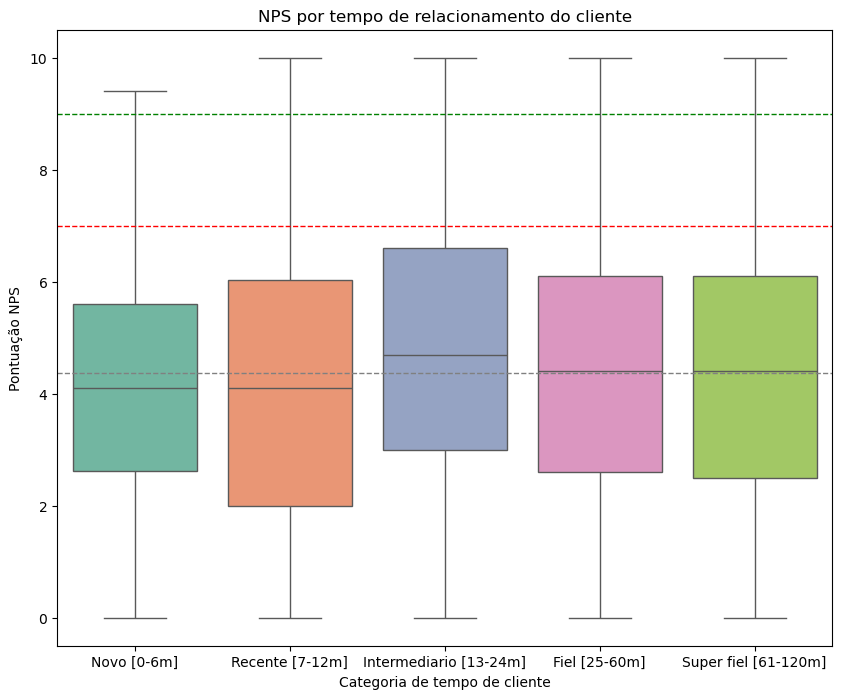

In [35]:
# Criar categorias de tempo de relacionamento
df_nps_processed['categoria_tempo_cliente'] = pd.cut(
    df_nps_processed['tempo_cliente_meses'],
    bins=[0, 6, 12, 24, 60, 120],
    labels=['Novo [0-6m]', 'Recente [7-12m]', 'Intermediario [13-24m]', 'Fiel [25-60m]', 'Super fiel [61-120m]']
)


# Calcular média e contagem por dia de atraso
tabela = (
    df_nps_processed.groupby('categoria_tempo_cliente')
    .agg(
        media_nps=('pontuacao_nps', 'mean'),
        contagem=('categoria_tempo_cliente', 'count')
    )
    .reset_index()
)

# Calcular percentual (mantendo tipo numérico)
tabela['percentual'] = (tabela['contagem'] / tabela['contagem'].sum()) * 100

# Adicionar linha de total geral
total = pd.DataFrame({
    'categoria_tempo_cliente': ['Total Geral'],
    'media_nps': [df_nps_processed['pontuacao_nps'].mean()],
    'contagem': [df_nps_processed.shape[0]],
    'percentual': [100.0]
})

# Concatenar e formatar
tabela = pd.concat([tabela, total], ignore_index=True)
tabela['media_nps'] = tabela['media_nps'].round(4)
tabela['percentual'] = tabela['percentual'].round(2)

# Renomear colunas
tabela = tabela.rename(columns={
    'Faixa de tempo de relacionamento': 'Rótulos de Linha',
    'media_nps': 'Média de pontuação NPS',
    'contagem': 'Contagem de clientes por faixa de tempo de relacionamento',
    'percentual': 'Perc de clientes por faixa de tempo de relacionamento (%)'
})

# Exibir tabela
print(tabela.to_string(index=False))

# Visualizar com boxplot
plt.figure(figsize=(10,8))
sns.boxplot(
    x='categoria_tempo_cliente',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set2'
)

# Linha da media global do NPS como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')
plt.title("NPS por tempo de relacionamento do cliente")
plt.xlabel("Categoria de tempo de cliente")
plt.ylabel("Pontuação NPS")
plt.show()

**Interpretando os dados:**

_A faixa de tempo de relacionamento da base de dados está entre 1 até 119 meses. No gráfico acima vemos que o NPS não varia muito por faixa de tempo de relacionamento (de novo a super fiel). A tabela nos mostra que os clientes fiéis (tenure de 25 a 60 meses) e super fiéis (com tenure maior que 60 meses) são mais de 50% da base de clientes, mesmo estes clientes tendem a ser mais detratores do que promotores, não fazendo muita diferença com clientes mais novos, recentes ou intermediários. O NPS médio para cada faixa está próximo da média geral do NPS de  **4,38**, o que indica um nível de satisfação baixo, sugerindo predominância de clientes neutros e detratores, com baixa presença de promotores. Ou seja, somente o tempo de relacionamento do cliente não é determinante direto da satisfação medida pelo NPS._

_O resultado também está de acordo com o **Mapa de Calor das correlações do NPS (target) com a tempo do cliente em meses (tenure)**, onde o valor da correlação negativa é de apenas **-0,01**, visto no item **3.8**._

_Também é compatível com o resultado do gráfico de Pairplot visto no item **3.13.3**, onde temos uma dispersão ampla, sem uma correlação clara ou linear entre o `NPS` e a `tempo do cliente (tenure)`._

### **3.17** Qualidade da entrega: quanto mais atraso, menor NPS?

#### Existe um ponto de ruptura em relação ao atraso de entrega (dias)?

Vamos calcular a média de NPS por dia de atraso, para verificar se atrasos impactam negativamente a satisfação do cliente (NPS).

Rótulos de Linha  Média de pontuação NPS  Contagem de atraso de entregas  Perc de atraso de entregas (%)
               0                  6.8567                             277                           11.08
               1                  5.5462                             615                           24.60
               2                  4.5802                             646                           25.84
               3                  3.4368                             525                           21.00
               4                  2.4444                             270                           10.80
               5                  1.4810                             116                            4.64
               6                  1.0971                              34                            1.36
               7                  0.2929                              14                            0.56
               8                  0.0000               

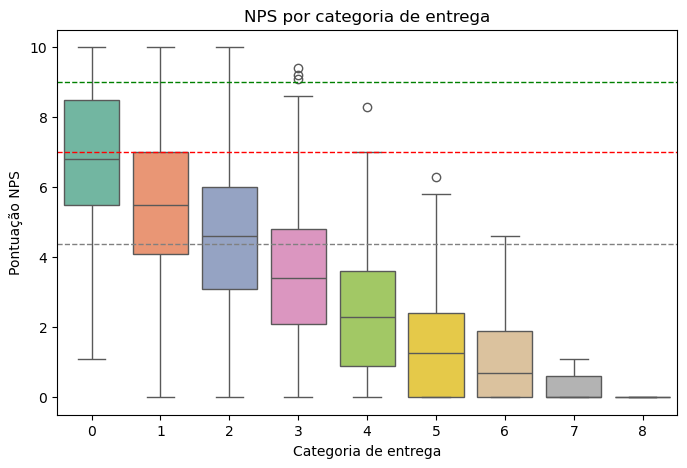

In [36]:
# Calcular média e contagem por dia de atraso
tabela = (
    df_nps_processed.groupby('atraso_entrega_dias')
    .agg(
        media_nps=('pontuacao_nps', 'mean'),
        contagem=('atraso_entrega_dias', 'count')
    )
    .reset_index()
)

# Calcular percentual (mantendo tipo numérico)
tabela['percentual'] = (tabela['contagem'] / tabela['contagem'].sum()) * 100

# Adicionar linha de total geral
total = pd.DataFrame({
    'atraso_entrega_dias': ['Total Geral'],
    'media_nps': [df_nps_processed['pontuacao_nps'].mean()],
    'contagem': [df_nps_processed.shape[0]],
    'percentual': [100.0]
})

# Concatenar e formatar
tabela = pd.concat([tabela, total], ignore_index=True)
tabela['media_nps'] = tabela['media_nps'].round(4)
tabela['percentual'] = tabela['percentual'].round(2)

# Renomear colunas
tabela = tabela.rename(columns={
    'atraso_entrega_dias': 'Rótulos de Linha',
    'media_nps': 'Média de pontuação NPS',
    'contagem': 'Contagem de atraso de entregas',
    'percentual': 'Perc de atraso de entregas (%)'
})

# Exibir tabela
print(tabela.to_string(index=False))

# Visualizar com boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    x='atraso_entrega_dias',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set2'
)
# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')
plt.title("NPS por categoria de entrega")
plt.xlabel("Categoria de entrega")
plt.ylabel("Pontuação NPS")
plt.show()


   atraso_entrega_dias  perc_detratores
0                    0        51.624549
1                    1        73.983740
2                    2        87.925697
3                    3        96.761905
4                    4        99.259259
5                    5       100.000000
6                    6       100.000000
7                    7       100.000000
8                    8       100.000000


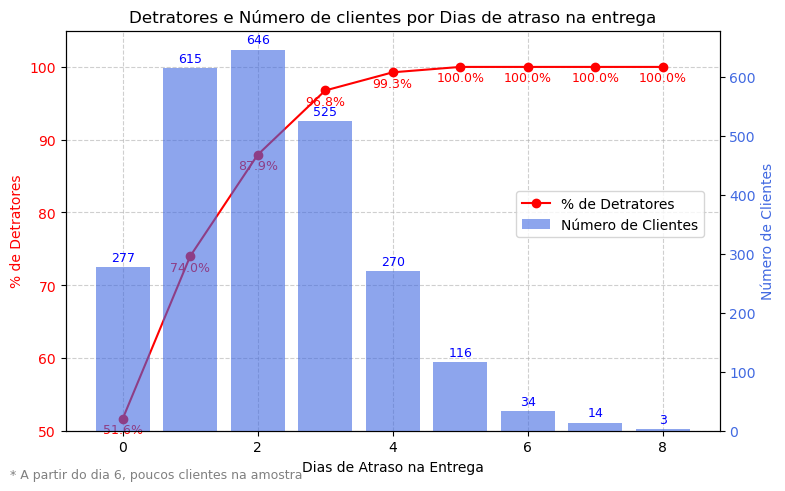

In [37]:
# Percentual de detratores (notas <= 6) por grupo
pontos_ruptura = (
    df_nps_processed
    .groupby('atraso_entrega_dias')['pontuacao_nps']
    .apply(lambda x: (x < 7).mean() * 100)
    .reset_index(name='perc_detratores')
)

print(pontos_ruptura)

# Classificar clientes conforme NPS
df_nps_processed['nps_category'] = df_nps_processed['pontuacao_nps'].apply(
    lambda x: 'Promotor' if x >= 9 else ('Neutro' if x >= 7 else 'Detrator')
)

# Calcular total de clientes e % de detratores por dia de atraso
tabela = (
    df_nps_processed.groupby('atraso_entrega_dias')['nps_category']
    .value_counts()
    .unstack(fill_value=0)
)

# Adicionar coluna de total e percentual de detratores
tabela['Total'] = tabela.sum(axis=1)
tabela['Pct_Detratores'] = (tabela['Detrator'] / tabela['Total']) * 100

# Criar gráfico com dois eixos
fig, ax1 = plt.subplots(figsize=(8, 5))

# Linha vermelha: % de detratores
ax1.plot(tabela.index, tabela['Pct_Detratores'], color='red', marker='o', label='% de Detratores')
ax1.set_xlabel('Dias de Atraso na Entrega')
ax1.set_ylabel('% de Detratores', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(50, 105)
ax1.grid(True, linestyle='--', alpha=0.6)

# Adicionar rótulos de porcentagem
for x, y in zip(tabela.index, tabela['Pct_Detratores']):
    ax1.text(x, y - 2, f'{y:.1f}%', ha='center', color='red', fontsize=9)

# Eixo da direita: número de clientes
ax2 = ax1.twinx()
ax2.bar(tabela.index, tabela['Total'], color='royalblue', alpha=0.6, label='Número de Clientes')
ax2.set_ylabel('Número de Clientes', color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')

# Adicionar rótulos de número de clientes
for x, y in zip(tabela.index, tabela['Total']):
    ax2.text(x, y + 10, f'{int(y)}', ha='center', color='blue', fontsize=9)

# Título e legenda
plt.title('Detratores e Número de clientes por Dias de atraso na entrega')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.5))
plt.text(0.5, -80, '* A partir do dia 6, poucos clientes na amostra', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


**Como analisar os dados acima?** 

_Para cada dia de atraso, diminui o NPS e aumenta a quantidade de clientes detratores. No eixo X temos o valor dos dias de atraso na entrega, como a base de dados varia de 0 a 8, preferimos não segmentar mais. No eixo Y, temos a porcentagem de detratores para cada dia de atraso (esquerda) / número de clientes (direita). **Temos um ponto de ruptura visível entre os dias 2 (87.9%) e 3 (96.8%) para uma quantidade grande de clientes, indicando que entre o 2º e 3º dia de atraso quase todos os clientes se tornaram detratores.**_

In [38]:
# Teste de Mann-Whitney

from scipy.stats import mannwhitneyu

# Exemplo: comparar NPS de entregas com até 2 dias de atraso vs. acima de 2 dias
grupo_ate2 = df_nps_processed[df_nps_processed['atraso_entrega_dias'] <= 2]['pontuacao_nps']
grupo_acima2 = df_nps_processed[df_nps_processed['atraso_entrega_dias'] > 2]['pontuacao_nps']

# Aplicar o teste de Mann-Whitney
stat, p_value = mannwhitneyu(grupo_ate2, grupo_acima2, alternative='two-sided')

print(f'Estatística U = {stat:.2f}')
print(f'Valor-p = {p_value:.4f}')

# Interpretar o resultado
if p_value < 0.05:
    print('Diferença significativa entre os grupos (p < 0.05)')
else:
    print('Não há diferença significativa entre os grupos (p >= 0.05)')


Estatística U = 1183034.00
Valor-p = 0.0000
Diferença significativa entre os grupos (p < 0.05)


**Isso é coincidência ou é real?**

_O teste de Mann-Whitney acima responde isso. Ele mistura os dois grupos ('atraso_entrega_dias' <= 2 e 'atraso_entrega_dias' > 2), ordena todo mundo do menor NPS pro maior, e verifica se os clientes de um grupo estão sistematicamente lá embaixo._

_O resultado é um p-value:_

_p < 0,05 : não é coincidência, a diferença é real_

_p > 0,05 :  pode ser sorte, não dá pra afirmar nada_

_**Conclusão: o resultado **p < 0.05** confirmou que não é coincidência, a diferença é real. O atraso no tempo de entrega, sozinho, tem efeito detectável no NPS da base. Com ponto de ruptura entre o 2º e o 3º dia de atraso.**_

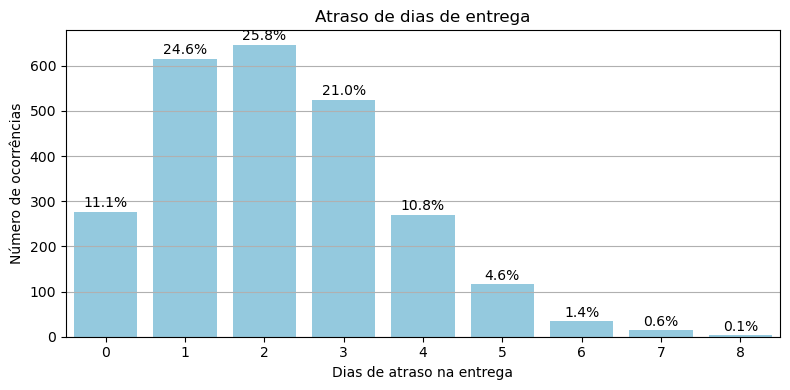

In [39]:
# Contagem de ocorrências por dia de atraso
contagem_atrasos = df_nps_processed['atraso_entrega_dias'].value_counts().sort_index()

# Filtrar apenas os dias de 0 a 8
contagem_atrasos = contagem_atrasos.loc[0:8]

# Calcular proporção (%)
total = contagem_atrasos.sum()
proporcoes = (contagem_atrasos / total) * 100

# Plotar gráfico de barras
plt.figure(figsize=(8,4))
ax = sns.barplot(
    x=contagem_atrasos.index,
    y=contagem_atrasos.values,
    color='skyblue'
)

# Adicionar proporção (%) acima de cada barra
for i, (valor, prop) in enumerate(zip(contagem_atrasos.values, proporcoes.values)):
    ax.text(i, valor + 10, f"{prop:.1f}%", ha='center', fontsize=10, color='black')

plt.title("Atraso de dias de entrega")
plt.xlabel("Dias de atraso na entrega")
plt.ylabel("Número de ocorrências")

# Ajustar eixo x para mostrar exatamente de 0 a 8
plt.xlim(-0.5, 8.5)
plt.xticks(range(0,9))

plt.grid(axis='y')
plt.tight_layout()
plt.show()


Os clientes já começam a avaliar negativamente após o segundo dia de atraso, ou seja, do 3º dia em diante. A porcentagem de pedidos atrasados após 2 dias corresponde a 38,5% do total de entregas.

Nível de problema (suporte + reclamação): quanto mais contato, pior o NPS.

Criada a métrica nivel_contato_reclamacao somando contatos com suporte e reclamações.

Categorias: baixo, moderado, alto, muito alto, extremo.

Exibe um boxplot para comparar a distribuição de NPS conforme aumenta o nível de contato/reclamação.

👉 Assim você consegue verificar se clientes que entram em contato muitas vezes ou reclamam mais tendem a dar notas mais baixas de NPS.


                                  mean      sum perc_sum
categoria_contato_reclamacao                            
baixo                         7.675824    698.5     6.5%
moderado                      5.753828   2479.9   23.07%
alto                          4.649663   3445.4   32.05%
muito alto                    3.546132   3805.0   35.39%
extremo                       2.282270    321.8    2.99%
Total_Geral                   4.378600  10946.5     100%


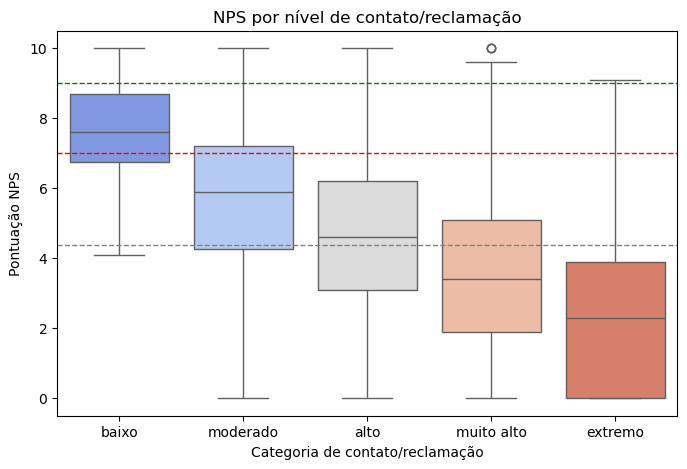

In [40]:
# Criar variável de nível de contato/reclamação
df_nps_processed['nivel_contato_reclamacao'] = (
    df_nps_processed['contatos_suporte'] +
    df_nps_processed['quantidade_reclamacoes']
)

# Categorizar em faixas de intensidade
df_nps_processed['categoria_contato_reclamacao'] = pd.cut(
    df_nps_processed['nivel_contato_reclamacao'],
    bins=[0, 1, 3, 5, 10, 50],
    labels=['baixo', 'moderado', 'alto', 'muito alto', 'extremo']
)

# Calcular média do NPS e soma por categoria
tabela = df_nps_processed.groupby('categoria_contato_reclamacao')[
    'pontuacao_nps'
].agg(['mean', 'sum'])

# calcula porcentagem da soma
total = tabela['sum'].sum()
tabela['perc_sum'] = (tabela['sum'] / total) * 100

# formatação com %
tabela['perc_sum'] = tabela['perc_sum'].round(2).astype(str) + '%'

# adiciona linha "Geral"
tabela.loc['Total_Geral', 'mean'] = df_nps_processed['pontuacao_nps'].mean()
tabela.loc['Total_Geral', 'sum'] = df_nps_processed['pontuacao_nps'].sum()
tabela.loc['Total_Geral', 'perc_sum'] = '100%'

print(tabela)

# Visualizar com boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    x='categoria_contato_reclamacao',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='coolwarm'
)
# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='≤Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')
plt.title("NPS por nível de contato/reclamação")
plt.xlabel("Categoria de contato/reclamação")
plt.ylabel("Pontuação NPS")
# plt.legend()
plt.show()


📉 O breakpoint está entre baixo e moderado, porque é nesse ponto que o NPS médio cruza a linha vermelha de 6, saindo da zona neutra e entrando na zona de detratores.

👉 Em outras palavras:

Clientes com baixo nível de contato/reclamação ainda estão relativamente satisfeitos (neutros).

A partir do nível moderado, a percepção muda drasticamente e o NPS cai para a faixa negativa.

Perfil de compra: clientes premium têm maior satisfação?

Cria categorias (baixo, moderado, alto, premium, luxo) com base em faixas de valor

                            mean      sum perc_sum
categoria_ticket_medio                            
baixo                   4.212335   1912.4   17.47%
moderado                4.412809   2859.5   26.12%
alto                    4.454242   3202.6   29.26%
premium                 4.356069   2260.8   20.65%
luxo                    4.445000    711.2     6.5%
Total_Geral             4.378600  10946.5     100%


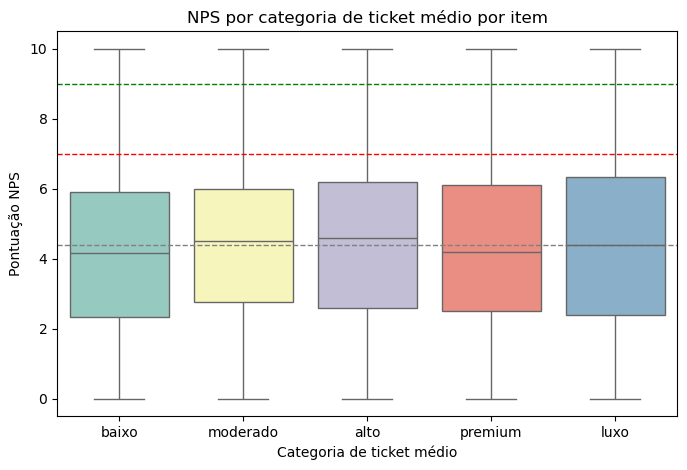

In [41]:
# Criar variável de ticket médio por item
df_nps_processed['ticket_medio_item'] = (
    df_nps_processed['valor_pedido'] /
    df_nps_processed['quantidade_itens']
)

# Categorizar ticket médio em faixas
df_nps_processed['categoria_ticket_medio'] = pd.cut(
    df_nps_processed['ticket_medio_item'],
    bins=[0, 50, 100, 200, 500, 2000],
    labels=['baixo', 'moderado', 'alto', 'premium', 'luxo']
)

# Calcular média de NPS por categoria de ticket médio
tabela = df_nps_processed.groupby('categoria_ticket_medio')[
    'pontuacao_nps'
].agg(['mean', 'sum'])

# calcula porcentagem da soma
total = tabela['sum'].sum()
tabela['perc_sum'] = (tabela['sum'] / total) * 100

# formatação com %
tabela['perc_sum'] = tabela['perc_sum'].round(2).astype(str) + '%'

# adiciona linha "Geral"
tabela.loc['Total_Geral', 'mean'] = df_nps_processed['pontuacao_nps'].mean()
tabela.loc['Total_Geral', 'sum'] = df_nps_processed['pontuacao_nps'].sum()
tabela.loc['Total_Geral', 'perc_sum'] = '100%'
print(tabela)

# Visualizar com boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    x='categoria_ticket_medio',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set3'
)
# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')
plt.title("NPS por categoria de ticket médio por item")
plt.xlabel("Categoria de ticket médio")
plt.ylabel("Pontuação NPS")
plt.show()


📊 Médias de NPS por categoria de ticket médio

baixo: 4,21

moderado: 4,41

alto: 4,45

premium: 4,36

luxo: 4,45

🔎 Interpretação
Todas as categorias estão bem abaixo da linha de 6, ou seja, já na faixa de detratores.

Não há um breakpoint claro como vimos no caso de contato/reclamação, porque os valores se mantêm praticamente estáveis entre 4,2 e 4,5.

Isso sugere que o ticket médio por item não influencia significativamente o NPS: independentemente de gastar pouco ou muito, os clientes avaliam de forma semelhante.

👉 Em outras palavras, o NPS é consistentemente baixo em todas as faixas de ticket médio, indicando que o valor gasto não é o fator determinante da insatisfação.

Sensibilidade a desconto: quem recebe mais desconto avalia melhor?

                        mean      sum perc_sum
categoria_desconto                            
até 5%              4.475332   5061.6   46.89%
5-10%               4.227986   2371.9   21.97%
10-20%              4.357210   1843.1   17.07%
20-50%              4.335052   1261.5   11.69%
50-100%             4.345763    256.4    2.38%
Total_Geral         4.378600  10946.5     100%


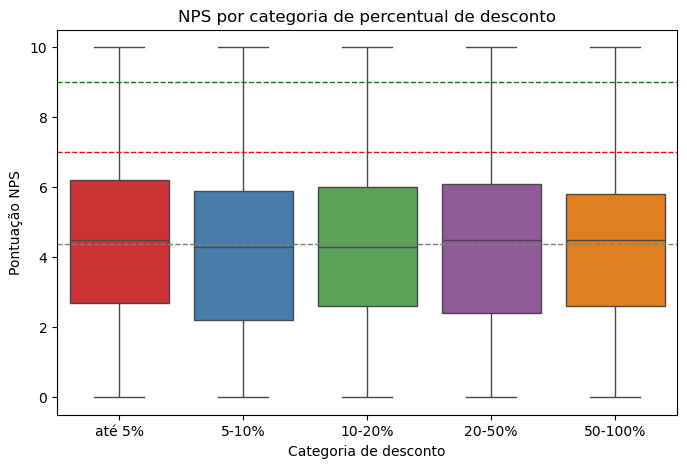

In [42]:
# Criar variável percentual de desconto
df_nps_processed['percentual_desconto'] = (
    df_nps_processed['valor_desconto'] /
    df_nps_processed['valor_pedido']
) * 100

# Categorizar percentual de desconto em faixas
df_nps_processed['categoria_desconto'] = pd.cut(
    df_nps_processed['percentual_desconto'],
    bins=[0, 5, 10, 20, 50, 100],
    labels=['até 5%', '5-10%', '10-20%', '20-50%', '50-100%']
)

# Calcular média de NPS por categoria de desconto
tabela = df_nps_processed.groupby('categoria_desconto')[
    'pontuacao_nps'
].agg(['mean', 'sum'])

# calcula porcentagem da soma
total = tabela['sum'].sum()
tabela['perc_sum'] = (tabela['sum'] / total) * 100

# formatação com %
tabela['perc_sum'] = tabela['perc_sum'].round(2).astype(str) + '%'

# adiciona linha "Geral"
tabela.loc['Total_Geral', 'mean'] = df_nps_processed['pontuacao_nps'].mean()
tabela.loc['Total_Geral', 'sum'] = df_nps_processed['pontuacao_nps'].sum()
tabela.loc['Total_Geral', 'perc_sum'] = '100%'
print(tabela)

# Visualizar com boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    x='categoria_desconto',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set1'
)
# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')
plt.title("NPS por categoria de percentual de desconto")
plt.xlabel("Categoria de desconto")
plt.ylabel("Pontuação NPS")
plt.show()

Segmento de comportamento:clientes recorrentes têm NPS maior?

                    mean      sum perc_sum
perfil_cliente                            
novo            3.936196   8982.4   82.06%
recorrente      9.009633   1964.1   17.94%
Total_Geral     4.378600  10946.5     100%


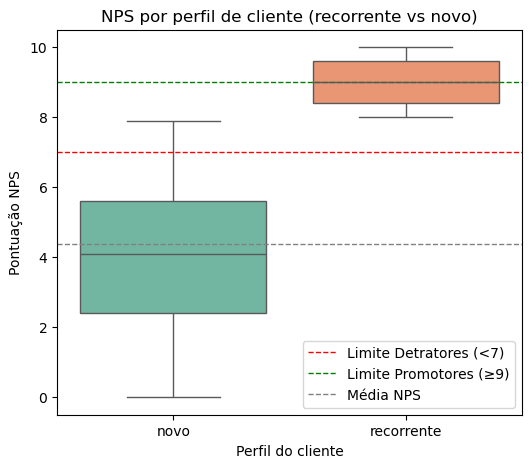

In [43]:
# Criar variável de perfil de cliente (recorrente ou novo)
df_nps_processed['perfil_cliente'] = df_nps_processed['recompra_30d'].map({
    1: 'recorrente',
    0: 'novo'
})

# Calcular média de NPS por perfil
tabela = df_nps_processed.groupby('perfil_cliente')[
    'pontuacao_nps'
].agg(['mean', 'sum'])

# calcula porcentagem da soma
total = tabela['sum'].sum()
tabela['perc_sum'] = (tabela['sum'] / total) * 100

# formatação com %
tabela['perc_sum'] = tabela['perc_sum'].round(2).astype(str) + '%'

# adiciona linha "Geral"
tabela.loc['Total_Geral', 'mean'] = df_nps_processed['pontuacao_nps'].mean()
tabela.loc['Total_Geral', 'sum'] = df_nps_processed['pontuacao_nps'].sum()
tabela.loc['Total_Geral', 'perc_sum'] = '100%'

print(tabela)

# Visualizar com boxplot
plt.figure(figsize=(6,5))
sns.boxplot(
    x='perfil_cliente',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set2'
)
# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')
plt.title("NPS por perfil de cliente (recorrente vs novo)")
plt.xlabel("Perfil do cliente")
plt.ylabel("Pontuação NPS")
plt.legend()
plt.show()


Segmento de comportamento: clientes com avaliação interna de satisfação (CSAT) mais alta têm NPS maior?

Categorias de CSAT: baixo, moderado, alto, excelente com base em faixas de pontuação.

                    mean      sum perc_sum
categoria_csat                            
baixo           4.012347   3607.1   36.14%
moderado        5.097964   4256.8   42.65%
alto            6.740230   1759.2   17.62%
excelente       8.341860    358.7    3.59%
Total_Geral     4.378600  10946.5     100%


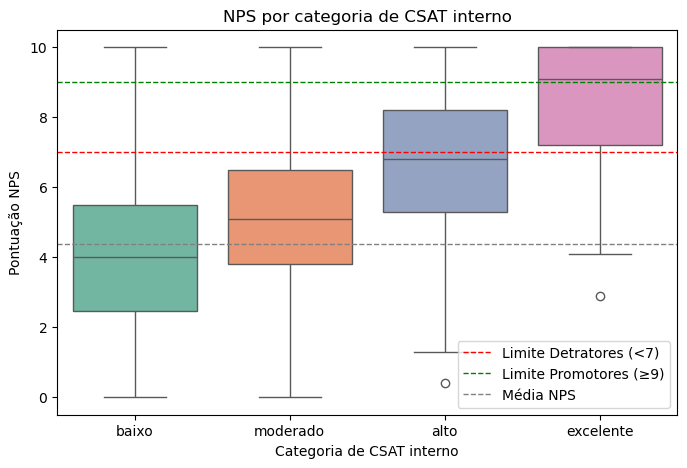

In [44]:
# Criar categorias de CSAT interno
df_nps_processed['categoria_csat'] = pd.cut(
    df_nps_processed['pontuacao_csat_interno'],
    bins=[0, 3, 6, 8, 10],
    labels=['baixo', 'moderado', 'alto', 'excelente']
)

# Calcular média de NPS por categoria de CSAT
tabela = df_nps_processed.groupby('categoria_csat')[
    'pontuacao_nps'
].agg(['mean', 'sum'])

# calcula porcentagem da soma
total = tabela['sum'].sum()
tabela['perc_sum'] = (tabela['sum'] / total) * 100

# formatação com %
tabela['perc_sum'] = tabela['perc_sum'].round(2).astype(str) + '%'

# adiciona linha "Geral"
tabela.loc['Total_Geral', 'mean'] = df_nps_processed['pontuacao_nps'].mean()
tabela.loc['Total_Geral', 'sum'] = df_nps_processed['pontuacao_nps'].sum()
tabela.loc['Total_Geral', 'perc_sum'] = '100%'
print(tabela)


# Visualizar com boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    x='categoria_csat',
    y='pontuacao_nps',
    data=df_nps_processed,
    palette='Set2'
)

# Linha da media global como referencia
media_global = df_nps_processed["pontuacao_nps"].mean()

# Linhas de referência para detratores e promotores
plt.axhline(y=7, color='red', linestyle='--', linewidth=1, label='Limite Detratores (<7)')
plt.axhline(y=9, color='green', linestyle='--', linewidth=1, label='Limite Promotores (≥9)')
plt.axhline(y=media_global, color='grey', linestyle='--', linewidth=1, label='Média NPS')

plt.title("NPS por categoria de CSAT interno")
plt.xlabel("Categoria de CSAT interno")
plt.ylabel("Pontuação NPS")
plt.legend()
plt.show()


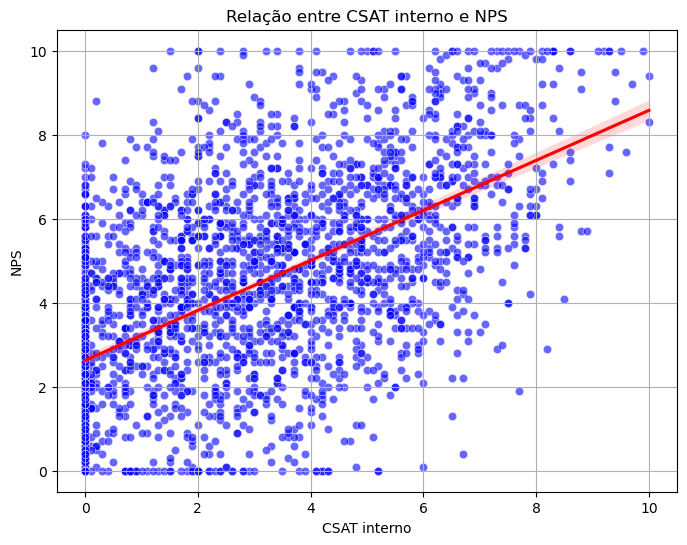

In [45]:
# Selecionar apenas as colunas de interesse
df_csat_nps = df_nps_processed[['pontuacao_csat_interno', 'pontuacao_nps']]

# Plotar gráfico de dispersão
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_csat_nps,
    x='pontuacao_csat_interno',
    y='pontuacao_nps',
    alpha=0.6,
    color='blue'
)

# Adicionar linha de tendência (regressão linear)
sns.regplot(
    data=df_csat_nps,
    x='pontuacao_csat_interno',
    y='pontuacao_nps',
    scatter=False,
    color='red'
)

plt.title("Relação entre CSAT interno e NPS")
plt.xlabel("CSAT interno")
plt.ylabel("NPS")
plt.grid(True)
plt.show()



--- INSIGHT DE NEGÓCIO: PONTO DE RUPTURA (AULA 1.3 EDA) ---
Objetivo: Identificar o marco onde a insatisfação ultrapassa 50% (Ponto de Ruptura).

O ponto de ruptura é o marco onde a insatisfação ultrapassa 50% — ou seja, quando mais da metade dos clientes está dando notas de detratores (0–6).
Esse ponto indica o limite crítico da experiência do cliente, onde o negócio começa a perder mais clientes do que fideliza.

📊 Como identificar:

Observe a distribuição das notas (como no gráfico que você mostrou).

Calcule a proporção acumulada de detratores.

O ponto em que essa proporção passa de 50% é o ponto de ruptura.

Por exemplo, se a maioria das notas está entre 4 e 5 e, somando até essa faixa, já temos mais de 50% dos clientes insatisfeitos, então o ponto de ruptura está entre 4 e 5.

In [46]:
import pandas as pd
import statsmodels.api as sm


X = df_nps_processed['atraso_entrega_dias']
y = df_nps_processed['pontuacao_nps']

# Adiciona constante para o intercepto
X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

# Coeficientes
b0 = modelo.params['const']
b1 = modelo.params['atraso_entrega_dias']

# Calcular ponto de ruptura para NPS = 5
ponto_ruptura = (4.38 - b0) / b1
print(f"Ponto de ruptura: {ponto_ruptura:.2f} dias de atraso")


                            OLS Regression Results                            
Dep. Variable:          pontuacao_nps   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     1385.
Date:                Fri, 26 Jun 2026   Prob (F-statistic):          1.31e-241
Time:                        22:04:12   Log-Likelihood:                -5296.3
No. Observations:                2500   AIC:                         1.060e+04
Df Residuals:                    2498   BIC:                         1.061e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   6.6332    

In [47]:
df_nps_processed.groupby(pd.cut(df_nps_processed['atraso_entrega_dias'], [0,1,2,3,4,5,6,7,8]))['pontuacao_nps'].mean()

atraso_entrega_dias
(0, 1]    5.546179
(1, 2]    4.580186
(2, 3]    3.436762
(3, 4]    2.444444
(4, 5]    1.481034
(5, 6]    1.097059
(6, 7]    0.292857
(7, 8]    0.000000
Name: pontuacao_nps, dtype: float64

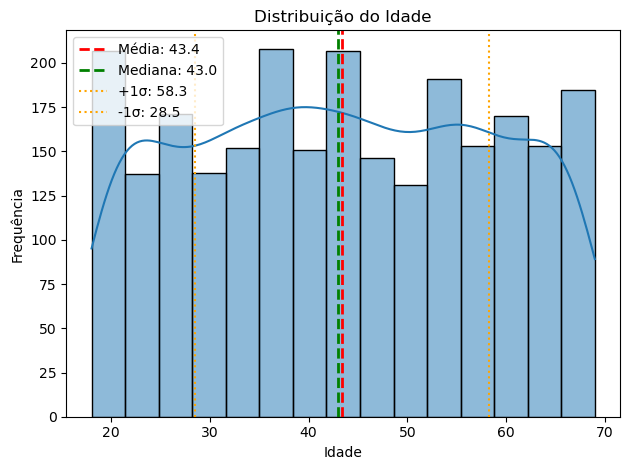

In [58]:
# Cálculo das estatísticas
media = df_nps_processed["idade_cliente"].mean()
mediana = df_nps_processed["idade_cliente"].median()
desvio_padrao = df_nps_processed["idade_cliente"].std()

# Criação do gráfico
sns.histplot(df_nps_processed["idade_cliente"], bins=15, kde=True)
plt.title("Distribuição do Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")

# Linhas verticais para as estatísticas
plt.axvline(media, color="red", linestyle="--", linewidth=2, label=f"Média: {media:.1f}")
plt.axvline(mediana, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.1f}")
plt.axvline(media + desvio_padrao, color="orange", linestyle=":", linewidth=1.5, label=f"+1σ: {media + desvio_padrao:.1f}")
plt.axvline(media - desvio_padrao, color="orange", linestyle=":", linewidth=1.5, label=f"-1σ: {media - desvio_padrao:.1f}")

# Legenda e layout
plt.legend()
plt.tight_layout()
plt.show()



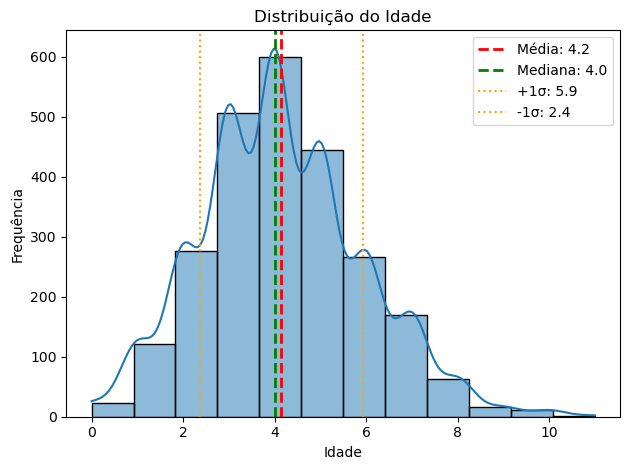

In [71]:
# Cálculo das estatísticas
media = df_nps_processed["quantidade_reclamacoes"].mean()
mediana = df_nps_processed["quantidade_reclamacoes"].median()
desvio_padrao = df_nps_processed["quantidade_reclamacoes"].std()

# Criação do gráfico
sns.histplot(df_nps_processed["quantidade_reclamacoes"], bins=12, kde=True)
plt.title("Distribuição do Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")

# Linhas verticais para as estatísticas
plt.axvline(media, color="red", linestyle="--", linewidth=2, label=f"Média: {media:.1f}")
plt.axvline(mediana, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.1f}")
plt.axvline(media + desvio_padrao, color="orange", linestyle=":", linewidth=1.5, label=f"+1σ: {media + desvio_padrao:.1f}")
plt.axvline(media - desvio_padrao, color="orange", linestyle=":", linewidth=1.5, label=f"-1σ: {media - desvio_padrao:.1f}")

# Legenda e layout
plt.legend()
plt.tight_layout()
plt.show()



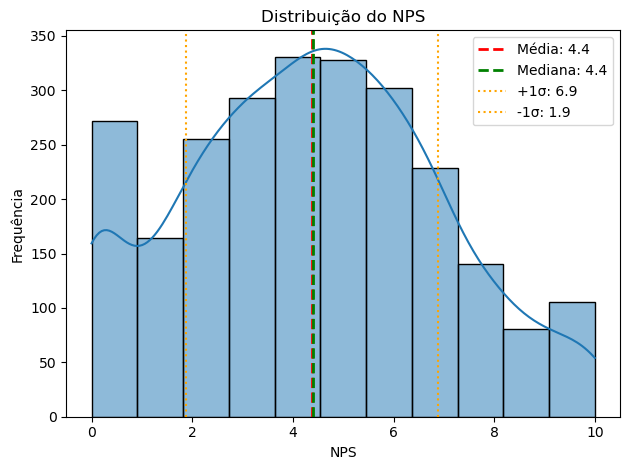

In [74]:
# Cálculo das estatísticas
media = df_nps_processed["pontuacao_nps"].mean()
mediana = df_nps_processed["pontuacao_nps"].median()
desvio_padrao = df_nps_processed["pontuacao_nps"].std()

# Criação do gráfico
sns.histplot(df_nps_processed["pontuacao_nps"], bins=11, kde=True)
plt.title("Distribuição do NPS")
plt.xlabel("NPS")
plt.ylabel("Frequência")

# Linhas verticais para as estatísticas
plt.axvline(media, color="red", linestyle="--", linewidth=2, label=f"Média: {media:.1f}")
plt.axvline(mediana, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.1f}")
plt.axvline(media + desvio_padrao, color="orange", linestyle=":", linewidth=1.5, label=f"+1σ: {media + desvio_padrao:.1f}")
plt.axvline(media - desvio_padrao, color="orange", linestyle=":", linewidth=1.5, label=f"-1σ: {media - desvio_padrao:.1f}")

# Legenda e layout
plt.legend()
plt.tight_layout()
plt.show()

